# **1. Set Up**

## **1.1 Package Installation**

Install necessary packages and import libraries for data cleaning, processing, model development, and evaluation

In [ ]:
!pip install gensim --upgrade

In [ ]:
!pip install pyspark

In [ ]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

In [ ]:
!java -version

openjdk version "11.0.26" 2025-01-21
OpenJDK Runtime Environment (build 11.0.26+4-post-Ubuntu-1ubuntu122.04)
OpenJDK 64-Bit Server VM (build 11.0.26+4-post-Ubuntu-1ubuntu122.04, mixed mode, sharing)


In [ ]:
!pip show pyspark

Name: pyspark
Version: 3.5.5
Summary: Apache Spark Python API
Home-page: https://github.com/apache/spark/tree/master/python
Author: Spark Developers
Author-email: dev@spark.apache.org
License: http://www.apache.org/licenses/LICENSE-2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: py4j
Required-by: google-spark-connect


In [ ]:
import pandas as pd
import ast
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import json
import math

In [ ]:
# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import BinaryClassificationEvaluator, RegressionEvaluator, ClusteringEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml import Pipeline
from pyspark.sql.functions import udf, col, expr, when, isnan, count, hour, to_timestamp, monotonically_increasing_id, explode, split, concat_ws, broadcast, row_number, log2, lit
import pyspark.sql.functions as F
from pyspark.ml.feature import Tokenizer, HashingTF, IDF
from pyspark.sql.types import StringType, IntegerType, DoubleType, MapType, ArrayType
from pyspark.sql.window import Window

import os
os.environ["PYSPARK_SUBMIT_ARGS"] = "--driver-memory 4g pyspark-shell"

# Check for an existing Spark session
if "spark" in locals():
    spark.stop()
    print("Existing Spark session stopped.")

# Create a SparkSession - the entry point to programming Spark with the DataFrame API
# Allocate 4GB memory for each executor
# An executor is a worker process that runs tasks on a cluster node as part of a Spark job.

spark = SparkSession.builder \
    .appName("BT4221 Group 18 Project") \
    .config("spark.driver.memory", "8g") \
    .config("spark.driver.maxResultSize", "4g")\
    .config("spark.executor.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

# Print the Spark version to confirm setup
print(f"Spark version: {spark.version}")

Spark version: 3.5.5


## **1.2 Download Data**

Both LinkedIn job postings and user profile datasets will be loaded from Google Drive and used throughout the remainder of this notebook.

In [ ]:
!pip install gdown
import gdown

# Download small dataset
gdown.download("https://drive.google.com/uc?id=11gBoHeh5BROJujWeBr0BnT7LbD4Sn7Vw", "linkedin_dataset.csv", quiet=False)

# Download Raw Job Skills Dataset
gdown.download("https://drive.google.com/uc?id=1plWLx-KENHUCdivSdEPpM5kGOG2tWRH8", "job_skills.csv", quiet=False)

# Download Raw Job Posting Dataset
gdown.download("https://drive.google.com/uc?id=1YDJUVPglGCvh7UyulB2mRnVWILpLmwSL", "job_postings.csv", quiet=False)

# Download large dataset (Merged)
gdown.download("https://drive.google.com/uc?id=1RT2jAVRMvT_-ZT3Nk3LvbUHO7b05GZo0", "linkedin_job_postings_and_skills.csv", quiet=False)

# Download CBF cache dataset
gdown.download("https://drive.google.com/uc?id=1Vh45b3MvZ8Yya29SqZnEWYiJI-PMlyYf", "cbf_output.csv", quiet=False)

# Download User-Interaction Matrix
gdown.download("https://drive.google.com/uc?id=16QvMKS1NNJpJiDxt2oM8XzR-aQudmpsd", "user_interaction.csv", quiet=False)


Downloading...
From: https://drive.google.com/uc?id=11gBoHeh5BROJujWeBr0BnT7LbD4Sn7Vw
To: /content/linkedin_dataset.csv
100%|██████████| 23.0M/23.0M [00:00<00:00, 50.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1plWLx-KENHUCdivSdEPpM5kGOG2tWRH8
From (redirected): https://drive.google.com/uc?id=1plWLx-KENHUCdivSdEPpM5kGOG2tWRH8&confirm=t&uuid=987a080f-5e2d-4684-a0e0-3591dc0e788d
To: /content/job_skills.csv
100%|██████████| 673M/673M [00:12<00:00, 55.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1YDJUVPglGCvh7UyulB2mRnVWILpLmwSL
From (redirected): https://drive.google.com/uc?id=1YDJUVPglGCvh7UyulB2mRnVWILpLmwSL&confirm=t&uuid=7a3eb559-b07b-466c-b804-2d52ab2fe41b
To: /content/job_postings.csv
100%|██████████| 415M/415M [00:05<00:00, 82.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1RT2jAVRMvT_-ZT3Nk3LvbUHO7b05GZo0
From (redirected): https://drive.google.com/uc?id=1RT2jAVRMvT_-ZT3Nk3LvbUHO7b05GZo0&confirm=t&uuid=3cf0b

'user_interaction.csv'

## **1.3 Upload Data**

Both Linkedin job postings and user profile datasets will be uploaded and initialised as `job_df` and `user_df`,

`job_post`: 1,296,381 rows and 14 features

`job_skill`: 1,348,488 and 2 features

`user_df`: 1,800 rows and 37 features (after filtering real LinkedIn profiles)

After Merging `job_post` & `job_skill` via inner:

`job_df`: 1,296,381 rows and 15 features

In [ ]:
user_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("multiLine", "true") \
    .option("quote", "\"") \
    .option("escape", "\"") \
    .option("inferSchema", "true") \
    .load("linkedin_dataset.csv")

In [ ]:
user_df.printSchema()  # user posting data

root
 |-- Intro: string (nullable = true)
 |-- Full Name: string (nullable = true)
 |-- Workplace: string (nullable = true)
 |-- Location: string (nullable = true)
 |-- Connections: integer (nullable = true)
 |-- Photo: string (nullable = true)
 |-- Followers: integer (nullable = true)
 |-- About: string (nullable = true)
 |-- Experiences: string (nullable = true)
 |-- Number of Experiences: integer (nullable = true)
 |-- Educations: string (nullable = true)
 |-- Number of Educations: integer (nullable = true)
 |-- Licenses: string (nullable = true)
 |-- Number of Licenses: integer (nullable = true)
 |-- Volunteering: string (nullable = true)
 |-- Number of Volunteering: integer (nullable = true)
 |-- Skills: string (nullable = true)
 |-- Number of Skills: integer (nullable = true)
 |-- Recommendations: string (nullable = true)
 |-- Number of Recommendations: integer (nullable = true)
 |-- Projects: string (nullable = true)
 |-- Number of Projects: integer (nullable = true)
 |-- Public

In [ ]:
user_df.show(5)

+--------------------+-------------------+--------------------+--------------------+-----------+-----+---------+--------------------+--------------------+---------------------+--------------------+--------------------+--------------------+------------------+------------+----------------------+--------------------+----------------+---------------+-------------------------+--------+------------------+------------+----------------------+-------+-----------------+------+----------------+--------------------+----------------+--------------------+-------------------+-------------+-----------------------+--------------------+-------------------+--------------------+--------------------+-----+
|               Intro|          Full Name|           Workplace|            Location|Connections|Photo|Followers|               About|         Experiences|Number of Experiences|          Educations|Number of Educations|            Licenses|Number of Licenses|Volunteering|Number of Volunteering|           

In [ ]:
job_post = spark.read.csv("job_postings.csv", header=True, inferSchema=True)

In [ ]:
job_post.printSchema()  # job posting data

root
 |-- job_link: string (nullable = true)
 |-- last_processed_time: string (nullable = true)
 |-- got_summary: string (nullable = true)
 |-- got_ner: string (nullable = true)
 |-- is_being_worked: string (nullable = true)
 |-- job_title: string (nullable = true)
 |-- company: string (nullable = true)
 |-- job_location: string (nullable = true)
 |-- first_seen: string (nullable = true)
 |-- search_city: string (nullable = true)
 |-- search_country: string (nullable = true)
 |-- search_position: string (nullable = true)
 |-- job_level: string (nullable = true)
 |-- job_type: string (nullable = true)



In [ ]:
job_post.show(5)

+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+-----------+--------------+--------------------+----------+--------+
|            job_link| last_processed_time|got_summary|got_ner|is_being_worked|           job_title|             company|        job_location|first_seen|search_city|search_country|     search_position| job_level|job_type|
+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+-----------+--------------+--------------------+----------+--------+
|https://www.linke...|2024-01-21 07:12:...|          t|      t|              f|Account Executive...|                  BD|       San Diego, CA|2024-01-15|   Coronado| United States|         Color Maker|Mid senior|  Onsite|
|https://www.linke...|2024-01-21 07:39:...|          t|      t|              f|Registered Nurse ...|   Trinity H

In [ ]:
job_skill = spark.read.csv("job_skills.csv", header=True, inferSchema=True)

In [ ]:
job_skill.printSchema()  # job skills data

root
 |-- job_link: string (nullable = true)
 |-- job_skills: string (nullable = true)



In [ ]:
job_skill.show(5)

+--------------------+--------------------+
|            job_link|          job_skills|
+--------------------+--------------------+
|https://www.linke...|Building Custodia...|
|https://www.linke...|Customer service,...|
|https://www.linke...|Applied Behavior ...|
|https://www.linke...|Electrical Engine...|
|https://www.linke...|Electrical Assemb...|
+--------------------+--------------------+
only showing top 5 rows



# **2. Data Cleaning (For all Models)**

## **2.1 Cleaning User Data**

Several **cleaning steps** were performed:

1) Filter Real Users: Only retain rows where `Label` == 0, to focus on real users and not AI-generated user profiles

2) Drop Irrelevant Columns: Dropped 28 features from `user_df` to remove any potential noise and focus on core profile attributes

3) Parse Experience: Converts the `skills` column from a stringified dictionary to a list of skills descriptions

4) Parse Experience: Converts the `experience` column from a stringified dictionary to a list of experience descriptions

In [ ]:
# Step 1: Filter rows where Label == 0
user_df = user_df.filter(col("Label") == 0)

# Step 2: Drop unnecessary columns
columns_to_drop = [
    'Intro','Photo','About', 'Label',
    'Number of Experiences', 'Educations',
    'Number of Educations','Licenses',
    'Number of Licenses','Volunteering',
    'Number of Volunteering','Recommendations',
    'Number of Recommendations','Projects','Number of Projects',
    'Publications','Number of Publications','Courses', 'Number of Courses',
    'Honors','Number of Honors','Scores','Number of Scores',
    'Languages', 'Number of Languages',
    'Organizations', 'Number of Organizations',
    'Interests', 'Number of Interests',
    'Activities', 'Number of Activities'
]
user_df = user_df.drop(*columns_to_drop)

# Step 3: Parse the Skills and Experiences and extract as a list
def parse_udf(x):
    try:
        d = ast.literal_eval(x)
        return list(d.values())
    except:
        return []

parse = udf(parse_udf, ArrayType(StringType()))
user_df = user_df.withColumn("Skills_List", parse(col("Skills")))
user_df = user_df.withColumn("Experience_List", parse(col("Experiences")))

user_df.show()

+--------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+
|           Full Name|           Workplace|            Location|Connections|Followers|         Experiences|              Skills|Number of Skills|         Skills_List|     Experience_List|
+--------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+
|  Adriano Lujan, MPA|Marketing and Gro...|Albuquerque, New ...|        233|      233|{'0': {'Role': 'M...|{'Skill 0': 'Lead...|               3|[Leadership, Comm...|[{Role=Marketing ...|
|        Alanis Roman|Benefits Analyst ...|Dallas-Fort Worth...|        177|      178|{'0': {'Role': 'B...|{'Skill 0': 'Time...|               3|[Time Management,...|[{Role=Benefits A...|
|       Alec Driscoll|Online Gaming Exe...|       United Sta

In [ ]:
user_df.select("experience_list").show(truncate=False)


+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
user_df.printSchema()

root
 |-- Full Name: string (nullable = true)
 |-- Workplace: string (nullable = true)
 |-- Location: string (nullable = true)
 |-- Connections: integer (nullable = true)
 |-- Followers: integer (nullable = true)
 |-- Experiences: string (nullable = true)
 |-- Skills: string (nullable = true)
 |-- Number of Skills: integer (nullable = true)
 |-- Skills_List: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- Experience_List: array (nullable = true)
 |    |-- element: string (containsNull = true)



## **2.2 Cleaning Jobs Data**

**Merging job skill information with job postings**  
We enriched the job postings dataset by merging it with the corresponding job skill data based on `job_link`. This allows us to incorporate skill-level information directly into each job entry.

Removing irrelevant Columns: Dropped 8 features from `job_df`(merged df) to remove any potential noise and focus on core job attributes

In [ ]:
job_df = job_post.join(job_skill, on="job_link", how="inner")

In [ ]:
# Step 1: Drop unnecessary columns
columns_to_drop = [
    'last_processed_time',
    'first_seen',
    'search_position',
    'job_level',
    'job_type',
    'got_summary',
    'got_ner',
    'is_being_worked'
]

job_df = job_df.drop(*columns_to_drop)  # `errors='ignore'` skips if column doesn't exist

# Step 2 Convert job_location and job_skills to list
job_df = job_df.withColumn("job_skills_list", split("job_skills", ",")) \
       .withColumn("job_location_list", split("job_location", ","))

job_df.printSchema()
job_df.show(5)

root
 |-- job_link: string (nullable = true)
 |-- job_title: string (nullable = true)
 |-- company: string (nullable = true)
 |-- job_location: string (nullable = true)
 |-- search_city: string (nullable = true)
 |-- search_country: string (nullable = true)
 |-- job_skills: string (nullable = true)
 |-- job_skills_list: array (nullable = true)
 |    |-- element: string (containsNull = false)
 |-- job_location_list: array (nullable = true)
 |    |-- element: string (containsNull = false)

+--------------------+--------------------+-------------------+--------------------+------------+--------------+--------------------+--------------------+--------------------+
|            job_link|           job_title|            company|        job_location| search_city|search_country|          job_skills|     job_skills_list|   job_location_list|
+--------------------+--------------------+-------------------+--------------------+------------+--------------+--------------------+--------------------+-

Creating a clean copy for other models

In [ ]:
cleaned_user_df = user_df.select("*")
cleaned_job_df = job_df.select("*")

## **2.3 User Interaction Matrix**
> **Note:** The whole User Interaction Matrix section is commented out because generating the full user-job interaction matrix involves heavy pairwise computations and can be very time-consuming. To improve efficiency during development, the interaction matrix is generated once, saved as a CSV file, and reloaded when needed.*

Since Spark doesn't support nn.Embedding or nn.Linear, we will proceed with pytorch to generate the User Interaction Matrix

In [ ]:
# Bring the entire Spark DataFrame into memory
job_df.write.mode("overwrite").parquet("/content/job_df.parquet")
pd_job_df = pd.read_parquet("/content/job_df.parquet")
pd_user_df = user_df.toPandas()

### **2.3.1 Encode Categorical Features**

In [ ]:

from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
title_encoder = LabelEncoder()
company_encoder = LabelEncoder()
location_encoder = LabelEncoder()

pd_job_df['job_id'] = title_encoder.fit_transform(pd_job_df['job_title'])
pd_job_df['company_id'] = company_encoder.fit_transform(pd_job_df['company'])
pd_job_df['location_id'] = location_encoder.fit_transform(pd_job_df['job_location'])


user_encoder = LabelEncoder()
location_encoder = LabelEncoder()

pd_user_df['user_id'] = user_encoder.fit_transform(pd_user_df['Full Name'])
pd_user_df['location_id'] = location_encoder.fit_transform(pd_user_df['Location'])

# Export out the Label Encoding for later use.
pd_job_df.to_csv("job_df.csv", index=False)
pd_user_df.to_csv("user_df.csv", index=False)

### **2.3.2 Generate Job Skill Embeddings**

In [ ]:
'''
!pip install gensim --upgrade
from gensim.models import Word2Vec

# Train Word2Vec on all job skill lists
w2v_model = Word2Vec(sentences=pd_job_df['job_skills_list'].tolist(), vector_size=100, window=5, min_count=1, workers=4, epochs= 20)

def avg_vector(tokens, model, dim=100):
    vecs = [model.wv[token] for token in tokens if token in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

# Apply to job skills
pd_job_df['job_skill_vector'] = pd_job_df['job_skills_list'].apply(lambda x: avg_vector(x, w2v_model))
'''


### **2.3.3 Create Job Embedding Module**

In [ ]:
'''
import numpy as np
import torch
import torch.nn as nn
class JobEmbedding(nn.Module):
    def __init__(self, num_jobs, num_companies, num_locations,
                 job_id_emb_dim=32, company_emb_dim=16, loc_emb_dim=16,
                 skill_vector_dim=100):
        super(JobEmbedding, self).__init__()

        self.job_id_emb = nn.Embedding(num_jobs, job_id_emb_dim)
        self.company_emb = nn.Embedding(num_companies, company_emb_dim)
        self.location_emb = nn.Embedding(num_locations, loc_emb_dim)
        self.skill_proj = nn.Linear(skill_vector_dim, 32)

    def forward(self, job_ids, company_ids, location_ids, skill_vectors):
        jid_emb = self.job_id_emb(job_ids)               # [batch, 32]
        comp_emb = self.company_emb(company_ids)         # [batch, 16]
        loc_emb = self.location_emb(location_ids)        # [batch, 16]
        skill_emb = torch.relu(self.skill_proj(skill_vectors))  # [batch, 32]

        return torch.cat([jid_emb, comp_emb, loc_emb, skill_emb], dim=-1)  # [batch, 96]
'''


### **2.3.4 Prepare Inputs & Generate Job Embeddings for Training**

In [ ]:
'''
job_ids = torch.tensor(pd_job_df['job_id'].values, dtype=torch.long)
company_ids = torch.tensor(pd_job_df['company_id'].values, dtype=torch.long)
location_ids = torch.tensor(pd_job_df['location_id'].values, dtype=torch.long)
skill_vecs = torch.tensor(np.stack(pd_job_df['job_skill_vector'].values), dtype=torch.float32)

# Initialize embedder
job_embedder = JobEmbedding(
    num_jobs=len(title_encoder.classes_),
    num_companies=len(company_encoder.classes_),
    num_locations=len(location_encoder.classes_)
)

# Get final job vectors
job_representations = job_embedder(job_ids, company_ids, location_ids, skill_vecs)
'''

### **2.3.5 Generate User Skills & Experience Embeddings**

In [ ]:
'''

# Combine skills and experiences into one corpus
corpus = pd_user_df['Skills_List'].tolist() + pd_user_df['Experience_List'].tolist()

# Train Word2Vec
w2v_model = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=1, workers=4, epochs=100)

# Vector helper
def average_vector(tokens, model, dim=100):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(dim)

# Add Word2Vec features
pd_user_df['skill_vector'] = pd_user_df['Skills_List'].apply(lambda x: average_vector(x, w2v_model))
pd_user_df['experience_vector'] = pd_user_df['Experience_List'].apply(lambda x: average_vector(x, w2v_model))
'''

### **2.3.6 Generating User-Job Interaction Labels**


#### Simulate "Likes" Based on Skill Similarity

To generate implicit feedback for training, we simulate user "likes" by selecting the top 5 job postings with the highest skill vector similarity for each user. This uses cosine similarity between user skill vectors and job skill vectors.


In [ ]:
'''
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import numpy as np

top_job_ids = []
top_job_titles = []
top_job_scores = []

# Preload job info
job_id_list = pd_job_df['job_id'].values
job_title_list = pd_job_df['job_title'].values
job_locations = pd_job_df['location_id'].values
job_skill_vectors = np.stack(pd_job_df['job_skill_vector'].values)

# Loop through each user
for idx, row in tqdm(pd_user_df.iterrows(), total=len(pd_user_df), desc="Recommending jobs"):
    user_loc = row['location_id']
    user_vec = row['skill_vector']

    # Step 1: Filter jobs by location
    matching_job_idxs = np.where(job_locations == user_loc)[0]
    fallback_to_all = False

    if len(matching_job_idxs) > 0:
        job_vecs_local = job_skill_vectors[matching_job_idxs]
        sims_local = cosine_similarity(user_vec.reshape(1, -1), job_vecs_local)[0]
        high_sim_count = np.sum(sims_local >= 0.75)
        if high_sim_count < 5:
            fallback_to_all = True
    else:
        fallback_to_all = True

    # Step 2: Decide job pool
    if fallback_to_all:
        job_vecs_to_compare = job_skill_vectors
        job_ids = job_id_list
        job_titles = job_title_list
    else:
        job_vecs_to_compare = job_skill_vectors[matching_job_idxs]
        job_ids = job_id_list[matching_job_idxs]
        job_titles = job_title_list[matching_job_idxs]

    # Step 3: Compute similarity
    sims = cosine_similarity(user_vec.reshape(1, -1), job_vecs_to_compare)[0]

    # Step 4: Zip and deduplicate by job_id (keep highest similarity)
    job_tuples = list(zip(job_ids, job_titles, sims))
    job_dict = {}  # job_id → (title, similarity)

    for jid, title, sim in job_tuples:
        if jid not in job_dict or sim > job_dict[jid][1]:
            job_dict[jid] = (title, sim)

    # Step 5: Sort unique jobs by similarity and get top 5
    sorted_jobs = sorted(job_dict.items(), key=lambda x: x[1][1], reverse=True)[:5]

    top_job_ids.append([jid for jid, _ in sorted_jobs])
    top_job_titles.append([title for _, (title, _) in sorted_jobs])
    top_job_scores.append([round(sim, 4) for _, (_, sim) in sorted_jobs])


pd_user_df['top_job_ids'] = top_job_ids
pd_user_df['top_job_titles'] = top_job_titles
pd_user_df['top_job_scores'] = top_job_scores
df_like = pd_user_df
'''

####  Simulate "Dislikes" Based on Skill Dissimilarity

To generate **negative interaction labels**, we simulate user "dislikes" by selecting the **bottom 5 job postings** with the **lowest cosine similarity** to each user's skill vector.


In [ ]:
'''
bottom_job_ids = []
bottom_job_titles = []
bottom_job_scores = []

# Preload job info
job_id_list = pd_job_df['job_id'].values
job_title_list = pd_job_df['job_title'].values
job_skill_vectors = np.stack(pd_job_df['job_skill_vector'].values)

# Loop through each user (no location filtering)
for idx, row in tqdm(pd_user_df.iterrows(), total=len(pd_user_df), desc="Recommending bottom jobs"):
    user_vec = row['skill_vector']  # already a 1D NumPy array

    # Step 1: Compute cosine similarity to all jobs
    sims = cosine_similarity(user_vec.reshape(1, -1), job_skill_vectors)[0]

    # Step 2: Zip and deduplicate by job_id (keep lowest similarity)
    job_tuples = list(zip(job_id_list, job_title_list, sims))
    job_dict = {}  # job_id → (title, similarity)

    for jid, title, sim in job_tuples:
        if jid not in job_dict or sim < job_dict[jid][1]:  # Keep lowest
            job_dict[jid] = (title, sim)

    # Step 3: Sort by similarity ascending → bottom 5
    sorted_jobs = sorted(job_dict.items(), key=lambda x: x[1][1])[:5]

    # Step 4: Store results
    bottom_job_ids.append([jid for jid, _ in sorted_jobs])
    bottom_job_titles.append([title for _, (title, _) in sorted_jobs])
    bottom_job_scores.append([round(sim, 4) for _, (_, sim) in sorted_jobs])

pd_user_df['bottom_job_ids'] = bottom_job_ids
pd_user_df['bottom_job_titles'] = bottom_job_titles
pd_user_df['bottom_job_scores'] = bottom_job_scores
df_dislike = pd_user_df
'''

#### Flatten and Label Positive Interactions

In [ ]:
'''
# Step 1: Ensure lists are properly formatted (if loaded from CSV)

for col in ['top_job_ids', 'top_job_titles', 'top_job_scores']:
    df_like[col] = df_like[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Explode the three columns
df_like_exploded = df_like.explode(['top_job_ids', 'top_job_titles', 'top_job_scores'])

# Step 3: Add label column
df_like_exploded['label'] = 1

# Step 4: Reset index (optional but recommended)
df_like_exploded.reset_index(drop=True, inplace=True)

df_like_exploded.head()
'''

#### Flatten and Label Negative Interactions

In [ ]:
'''
# Step 1: Ensure lists are properly formatted (if loaded from CSV)

for col in ['bottom_job_ids', 'bottom_job_titles', 'bottom_job_scores']:
    df_dislike[col] = df_dislike[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Explode the three columns
df_dislike_exploded = df_dislike.explode(['bottom_job_ids', 'bottom_job_titles', 'bottom_job_scores'])

# Step 3: Add label column
df_dislike_exploded['label'] = 0

# Step 4: Reset index (optional but recommended)
df_dislike_exploded.reset_index(drop=True, inplace=True)

df_dislike_exploded.head()
df_dislike_exploded.head()
'''

#### Merge Likes and Dislikes into a Final Interaction Dataset

In [ ]:
'''
# Step 1: Rename columns so both datasets match
df_like_exploded = df_like_exploded.rename(columns={
    'top_job_ids': 'job_id',
    'top_job_titles': 'job_title',
    'top_job_scores': 'job_score'
})

df_dislike_exploded = df_dislike_exploded.rename(columns={
    'bottom_job_ids': 'job_id',
    'bottom_job_titles': 'job_title',
    'bottom_job_scores': 'job_score'
})

# Step 2: Combine like (first) and dislike (second)
df_combined = pd.concat(
    [df_like_exploded, df_dislike_exploded],
    ignore_index=True
)
df_combined.head()
pd_user_df.to_csv("user_interaction.csv", index=False)
'''

# **3. Content-based Filtering**

Load Label Encodings generated above (from 2.3 User Interaction Matrix)

In [ ]:
# Converting back to spark dataframe to retain the Encodings
job_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("multiLine", "true") \
    .option("quote", "\"") \
    .option("escape", "\"") \
    .option("inferSchema", "true") \
    .load("job_df.csv")
user_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("multiLine", "true") \
    .option("quote", "\"") \
    .option("escape", "\"") \
    .option("inferSchema", "true") \
    .load("user_df.csv")

In [ ]:
user_df.printSchema()

root
 |-- Full Name: string (nullable = true)
 |-- Workplace: string (nullable = true)
 |-- Location: string (nullable = true)
 |-- Connections: integer (nullable = true)
 |-- Followers: integer (nullable = true)
 |-- Experiences: string (nullable = true)
 |-- Skills: string (nullable = true)
 |-- Number of Skills: integer (nullable = true)
 |-- Skills_List: string (nullable = true)
 |-- Experience_List: string (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- location_id: integer (nullable = true)



In [ ]:
job_df.printSchema()

root
 |-- job_link: string (nullable = true)
 |-- last_processed_time: timestamp (nullable = true)
 |-- got_summary: string (nullable = true)
 |-- got_ner: string (nullable = true)
 |-- is_being_worked: string (nullable = true)
 |-- job_title: string (nullable = true)
 |-- company: string (nullable = true)
 |-- job_location: string (nullable = true)
 |-- first_seen: string (nullable = true)
 |-- search_city: string (nullable = true)
 |-- search_country: string (nullable = true)
 |-- search_position: string (nullable = true)
 |-- job_level: string (nullable = true)
 |-- job_type: string (nullable = true)
 |-- job_skills: string (nullable = true)
 |-- job_id: integer (nullable = true)
 |-- company_id: integer (nullable = true)
 |-- location_id: integer (nullable = true)



In [ ]:
user_df.show()

+--------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+
|           Full Name|           Workplace|            Location|Connections|Followers|         Experiences|              Skills|Number of Skills|         Skills_List|     Experience_List|user_id|location_id|
+--------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+
|  Adriano Lujan, MPA|Marketing and Gro...|Albuquerque, New ...|        233|      233|{'0': {'Role': 'M...|{'Skill 0': 'Lead...|               3|['Leadership', 'C...|['{Role=Marketing...|     20|          6|
|        Alanis Roman|Benefits Analyst ...|Dallas-Fort Worth...|        177|      178|{'0': {'Role': 'B...|{'Skill 0': 'Time...|               3|['Time Management...|['

In [ ]:
job_df.show()

+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+---------------+--------------+--------------------+----------+--------+--------------------+------+----------+-----------+
|            job_link| last_processed_time|got_summary|got_ner|is_being_worked|           job_title|             company|        job_location|first_seen|    search_city|search_country|     search_position| job_level|job_type|          job_skills|job_id|company_id|location_id|
+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+---------------+--------------+--------------------+----------+--------+--------------------+------+----------+-----------+
|https://ae.linked...|2024-01-21 07:21:...|          t|      t|              f|        EVS Operator|              Sundus|Abu Dhabi, Abu Dh...|2024-01-17|   Saint Joseph|

## **3.1 Processing User Data**

Extract last (most recent) job role for each user from their list of experiences

In [ ]:
# Step 1: Create a UDF to parse and extract the last job role as a string
def extract_last_job_role_as_string(experience_str):
    try:
        # Load the experience string into a dictionary
        experience_dict = json.loads(experience_str.replace("'", "\""))

        # Extract the most recent job role (assuming '0' is the latest)
        if '0' in experience_dict:
            return experience_dict['0'].get('Role', '')
        else:
            return ''
    except Exception as e:
        return ''

# Register the UDF
extract_last_job_role_as_string_udf = udf(extract_last_job_role_as_string, StringType())

# Step 2: Apply the UDF to extract the last job role as a string
user_df = user_df.withColumn("Last_Job", extract_last_job_role_as_string_udf(col("experiences")))

# Step 3: Show the result
user_df.show()

+--------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+--------------------+
|           Full Name|           Workplace|            Location|Connections|Followers|         Experiences|              Skills|Number of Skills|         Skills_List|     Experience_List|user_id|location_id|            Last_Job|
+--------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+--------------------+
|  Adriano Lujan, MPA|Marketing and Gro...|Albuquerque, New ...|        233|      233|{'0': {'Role': 'M...|{'Skill 0': 'Lead...|               3|['Leadership', 'C...|['{Role=Marketing...|     20|          6|Marketing and Gro...|
|        Alanis Roman|Benefits Analyst ...|Dallas-Fort Worth...|        177|      17

In [ ]:
user_df.show(5)

+-------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+--------------------+
|          Full Name|           Workplace|            Location|Connections|Followers|         Experiences|              Skills|Number of Skills|         Skills_List|     Experience_List|user_id|location_id|            Last_Job|
+-------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+--------------------+
| Adriano Lujan, MPA|Marketing and Gro...|Albuquerque, New ...|        233|      233|{'0': {'Role': 'M...|{'Skill 0': 'Lead...|               3|['Leadership', 'C...|['{Role=Marketing...|     20|          6|Marketing and Gro...|
|       Alanis Roman|Benefits Analyst ...|Dallas-Fort Worth...|        177|      178|{'0

## **3.2 Processing Job Data**

Concatenate the `search_city` and `search_country` columns in job_df into a single location column. This unified location feature will be used in subsequent analysis and matching steps

In [ ]:
from pyspark.sql.functions import concat_ws

job_df = job_df.withColumn("job_loc", concat_ws(", ", col("search_city"), col("search_country")))

In [ ]:
job_df.show()

+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+---------------+--------------+--------------------+----------+--------+--------------------+------+----------+-----------+--------------------+
|            job_link| last_processed_time|got_summary|got_ner|is_being_worked|           job_title|             company|        job_location|first_seen|    search_city|search_country|     search_position| job_level|job_type|          job_skills|job_id|company_id|location_id|             job_loc|
+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+---------------+--------------+--------------------+----------+--------+--------------------+------+----------+-----------+--------------------+
|https://ae.linked...|2024-01-21 07:21:...|          t|      t|              f|        EVS Operator|      

In [ ]:
job_df.rdd.getNumPartitions()

1

Given that job_df is a large dataset, the number of partitions was increased to enable better parallelism

In [ ]:
job_df = job_df.repartition(150)
job_df.rdd.getNumPartitions()

150

## **3.3 Extracting sample**

A 20% sample split will be applied to `user_df` to exract the sample for building of Content-Based cosine similarity output. Due to the large dataset and lenghty runtime, we can only afford to obtain the sample of 20% for evaluation

In [ ]:
other_sample, user_sample = user_df.randomSplit([0.8, 0.2], seed=42)

In [ ]:
other_sample.show(5)
other_sample.count()

+-----------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+------------------+
|        Full Name|           Workplace|            Location|Connections|Followers|         Experiences|              Skills|Number of Skills|         Skills_List|     Experience_List|user_id|location_id|          Last_Job|
+-----------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+------------------+
|    "Gigi" Lucero|Senior Talent Acq...|Washington DC-Bal...|        500|     2746|{'0': {'Workplace...|{'Skill 0': 'Lead...|               3|['Lead Generation...|['{Role=, Workpla...|      0|        560|                  |
|A. Kenyatta Greer|Communications pr...|Atlanta Metropoli...|        500|      767|{'0': {'Workplace...|

1490

In [ ]:
user_sample.show(5)
user_sample.count()

+--------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+--------------------+
|           Full Name|           Workplace|            Location|Connections|Followers|         Experiences|              Skills|Number of Skills|         Skills_List|     Experience_List|user_id|location_id|            Last_Job|
+--------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+--------------------+
|ALPFA Rutgers-Newark|Leading Professio...|New York City Met...|        500|     1511|{'0': {'Role': 'A...|{'Skill 0': 'Team...|               3|['Team Building',...|['{Role=ALPFA Rut...|      2|        376|ALPFA Rutgers New...|
|          Abhi Shahi|Technology Risk G...| Greater Sydney Area|        500|     107

310

## **3.4 TF-IDF**

Step 1: Concatenate job_name/job_title with location/job_loc into a single string column for TF-IDF processing

In [ ]:
# For job_df
job_df = job_df.withColumn("combined_text", concat_ws(" ", job_df["job_title"], job_df["job_loc"]))

# For other_sample and user_sample (assuming location is also in these)
other_sample = other_sample.withColumn("combined_text", concat_ws(" ", other_sample["Last_Job"], other_sample["location"]))
user_sample = user_sample.withColumn("combined_text", concat_ws(" ", user_sample["Last_Job"], user_sample["location"]))

Step 2: Split the combined text into individual words (tokens)

In [ ]:
tokenizer = Tokenizer(inputCol="combined_text", outputCol="tokens")
job_df = tokenizer.transform(job_df)
other_sample = tokenizer.transform(other_sample)
user_sample = tokenizer.transform(user_sample)

Step 3: TF Vectorisation with the use of `HashingTF` to convert tokens into fixed-length term frequency vectors

Step 4: Fit an IDF model to down-weight common terms and emphasise unique ones

Step 5: TF-IDF transformation by applying the fitted IDF model to transform both `job_df` and `user_sample` data into TF-IDF vectors

In [ ]:
# Combine for IDF fitting
combined = job_df.select("tokens").union(other_sample.select("tokens"))

hashingTF = HashingTF(inputCol="tokens", outputCol="raw_features", numFeatures=10000)
featurized = hashingTF.transform(combined)

idf = IDF(inputCol="raw_features", outputCol="features")
idf_model = idf.fit(featurized)

# Transform each set
job_df = hashingTF.transform(job_df)
job_df = idf_model.transform(job_df).withColumnRenamed("features", "job_vec")

user_sample = hashingTF.transform(user_sample)
user_sample = idf_model.transform(user_sample).withColumnRenamed("features", "user_vec")

In [ ]:
user_sample.show()

+--------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+--------------------+--------------------+--------------------+--------------------+--------------------+
|           Full Name|           Workplace|            Location|Connections|Followers|         Experiences|              Skills|Number of Skills|         Skills_List|     Experience_List|user_id|location_id|            Last_Job|       combined_text|              tokens|        raw_features|            user_vec|
+--------------------+--------------------+--------------------+-----------+---------+--------------------+--------------------+----------------+--------------------+--------------------+-------+-----------+--------------------+--------------------+--------------------+--------------------+--------------------+
|ALPFA Rutgers-Newark|Leading Professio...|New York City Met.

Generate all possible user–job pairs for similarity comparison, a cross join was performed between the test users and job postings. The `user_sample` is broadcasted to optimize the join, since it is relatively smaller compared to the `job_df`

In [ ]:
matched_df = broadcast(user_sample).select("Full Name", "user_id", "user_vec", "location", "Last_Job") \
    .crossJoin(job_df.select("job_id", "job_vec", "job_title", "company", "job_loc"))


To measure how well each job posting matches a user's location and most recent job experience, **cosine similarity** was computed between the user and job TF-IDF vectors. A custom UDF was used to calculate similarity for each user-job pair.

In [ ]:
def cosine_similarity(a, b):
    dot = float(a.dot(b))
    norm_a = math.sqrt(a.dot(a))
    norm_b = math.sqrt(b.dot(b))
    return float(dot / (norm_a * norm_b)) if norm_a != 0 and norm_b != 0 else 0.0

cosine_similarity_udf = udf(cosine_similarity, DoubleType())

matched_df = matched_df.withColumn("similarity", cosine_similarity_udf("user_vec", "job_vec"))

To avoid overly generic matches, a similarity score of 0.95 and above is considered 'perfect' similarity. Such scores will be set to 0.

In [ ]:
matched_df = matched_df.withColumn(
    "similarity",
    when(col("similarity") >= 0.95, 0).otherwise(col("similarity"))
)

In [ ]:
matched_df.show()
matched_df.count()

+--------------------+-------+--------------------+--------------------+--------------------+------+--------------------+--------------------+--------------+--------------------+--------------------+
|           Full Name|user_id|            user_vec|            location|            Last_Job|job_id|             job_vec|           job_title|       company|             job_loc|          similarity|
+--------------------+-------+--------------------+--------------------+--------------------+------+--------------------+--------------------+--------------+--------------------+--------------------+
|ALPFA Rutgers-Newark|      2|(10000,[360,585,4...|New York City Met...|ALPFA Rutgers New...|550770|(10000,[132,5945,...|Volunteer: Exerci...|VolunteerMatch|Spokane, United S...|                 0.0|
|          Abhi Shahi|      6|(10000,[3372,5649...| Greater Sydney Area|                    |550770|(10000,[132,5945,...|Volunteer: Exerci...|VolunteerMatch|Spokane, United S...|                 0.0|


401878110

In [ ]:
matched_df.rdd.getNumPartitions()

150

In [ ]:
matched_df = matched_df.drop("user_vec", "job_vec")
matched_df.show(20)

+--------------------+-------+--------------------+--------------------+------+--------------------+--------------+--------------------+--------------------+
|           Full Name|user_id|            location|            Last_Job|job_id|           job_title|       company|             job_loc|          similarity|
+--------------------+-------+--------------------+--------------------+------+--------------------+--------------+--------------------+--------------------+
|ALPFA Rutgers-Newark|      2|New York City Met...|ALPFA Rutgers New...|550770|Volunteer: Exerci...|VolunteerMatch|Spokane, United S...|                 0.0|
|          Abhi Shahi|      6| Greater Sydney Area|                    |550770|Volunteer: Exerci...|VolunteerMatch|Spokane, United S...|                 0.0|
|Abiola Afolayan, ...|      8|               Italy|Strategic Partner...|550770|Volunteer: Exerci...|VolunteerMatch|Spokane, United S...|                 0.0|
|          Adam White|     13|New York, New Yor...| 

In [ ]:
filtered_matched_df = matched_df.filter(matched_df.similarity > 0.5)

In [ ]:
filtered_matched_df.show()

+--------------------+-------+--------------------+--------------------+------+--------------------+--------------------+--------------------+------------------+
|           Full Name|user_id|            location|            Last_Job|job_id|           job_title|             company|             job_loc|        similarity|
+--------------------+-------+--------------------+--------------------+------+--------------------+--------------------+--------------------+------------------+
|Riley McClellan, MBA|   1434|       United States|Senior Account Ex...| 16688|Acquisition Accou...|       Revel Systems|Atlanta, United S...|0.5015810990565858|
|Riley McClellan, MBA|   1434|       United States|Senior Account Ex...|251085|Manager - Sales A...|        Uber Freight|Arkansas, United ...|0.5849402457099032|
|   Kavitha Prabhakar|    972|Chicago, Illinois...|           Principal|289013|OPERATIONS ASSIST...|  Dollar Tree Stores|Illinois, United ...|  0.51454700399515|
|Riley McClellan, MBA|   143

The output was computed and exported as CSV.

> **Note:** The full process of exporting takes approximately **1.5 hours to run**, so the output has been exported as a CSV and used directly in subsequent steps.

> **Reason:** Due to PySpark’s lazy evaluation model, transformations are not executed until an action is triggered. As the pipeline grows longer, each action triggers the entire computation graph, leading to significant delays. While .cache() can help reduce recomputation, it also consumes a large amount of memory. To avoid recomputation without overwhelming memory, we chose to persist the results via export and reload from disk, effectively resetting the computation lineage.

In [ ]:
'''
output_path = "output.csv"

temp_dir = "csv_output"

filtered_matched_df.write.option("header", "true").mode("overwrite").csv(temp_dir)
'''

In [ ]:
output_df = spark.read.csv("cbf_output.csv", header=True, inferSchema=True)
output_df.show(10)

+--------------------+-------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+------------------+
|           Full Name|user_id|            location|            Last_Job|    job_id|           job_title|             company|             job_loc|        similarity|
+--------------------+-------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+------------------+
|     Allison O'Neill|      9|Daytona Beach, Fl...|Group Inside Sale...|    148425|      Office Manager|        Aspen Dental|Daytona Beach, Un...|0.5055563130848959|
|Dr. Courtney L. M...|   1579|       United States|           Principal|     14447| Principal Architect|       Iron Mountain|Cohoes, United St...|0.5472926685366674|
|Dr. Courtney L. M...|   1579|       United States|           Principal|      7207| Principal Architect|       Iron Mountain|Lebanon, United S...|0.5463855040987405|
|Dr.

A window function is used to group the data by `user_id` and order the job postings within each group in descending order of similarity. Subsequently, a row number is assigned to each job within its user group using the `row_number()`function. Lastly, the `top_k` df retains only the ro where the rank is less than or equal to 10

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

windowSpec = Window.partitionBy("user_id").orderBy(col("similarity").desc())
top_k = output_df.withColumn("rank", row_number().over(windowSpec)).filter(col("rank") <= 10)

In [ ]:
top_k.show()

+-------------------+-------+--------------------+--------------------+-----------+--------------------+--------------------+--------------------+------------------+----+
|          Full Name|user_id|            location|            Last_Job|     job_id|           job_title|             company|             job_loc|        similarity|rank|
+-------------------+-------+--------------------+--------------------+-----------+--------------------+--------------------+--------------------+------------------+----+
|       Alanis Roman|      1|Dallas-Fort Worth...|    Benefits Analyst|25769825377|Territory Manager...|              Sciton|Garland, United S...|0.5462472511623426|   1|
|       Alex Whitlow|      6|London, England, ...|Research and Stra...|60129611750|    Strategy Manager|Jobs via eFinanci...|Greater London, U...| 0.522940447096367|   1|
|    Allison O'Neill|      9|Daytona Beach, Fl...|Group Inside Sale...|51539618203|Inside Sales Repr...|Corporate Client ...|Pompano Beach, Un...

## **3.5. Model Evaluation**

NDCG@10 is an evaluation metric used to evaluate the quality of job recommendations for each user

First, relevance is defined at `similarity` column > 0.55

Next it calculates the DCH for each recommendation using: relevance/log2(rank + 1), and sums it per user.

The ideal DCG assumes all top-10 items are relevant and perfectly ranked. NDCG is then computed by dividing DCG with IDCG, and the average NDCG score across users is then obtained.

In [ ]:
K = 10  # Cutoff for top-K
top_k = top_k.withColumn("rank", col("rank").cast("int"))  # ensure rank is int

top_k = top_k.withColumn(
    "relevance", when(col("similarity") > 0.55, 1).otherwise(0))

top_k = top_k.withColumn(
    "log_rank", log2(col("rank") + 1)
).withColumn(
    "dcg_component", col("relevance") / col("log_rank")
)

dcg_df = top_k.filter(col("rank") <= K).groupBy("user_id").agg(
    F.sum("dcg_component").alias("dcg")
)

def ideal_dcg(k):
    return sum([1 / math.log2(i + 2) for i in range(k)])  # i+2 since rank starts at 1

ideal_dcg_k = ideal_dcg(K)

ndcg_df = dcg_df.withColumn("idcg", lit(ideal_dcg_k)).withColumn(
    "ndcg", col("dcg") / col("idcg")
)

avg_ndcg = ndcg_df.select(F.avg("ndcg").alias("avg_ndcg")).collect()[0]["avg_ndcg"]
print(f"Average NDCG@{K}: {avg_ndcg:.4f}")


Average NDCG@10: 0.5115


Accuracy of the Top-10 job recommendations can also be computed using a similarity threshold. In this case, the threshold is set at 0.55.

The top_k DataFrame is then filtered to count how many of those recommendations have a similarity score greater than or equal to 0.55

Finally, accuracy is computed as by dividing the number of relevant recommendations over the number of recommendations in the top_k DataFrame

In [ ]:
from pyspark.sql.functions import avg, count, sum as Fsum

# Add binary relevance column
top_k = top_k.withColumn("is_correct", (col("similarity") >= 0.55).cast("int"))

# Calculate per-user accuracy
per_user_accuracy = top_k.groupBy("user_id").agg(
    (Fsum("is_correct") / count("*")).alias("accuracy")
)

# Average across all users
avg_accuracy = per_user_accuracy.select(avg("accuracy").alias("avg_topk_accuracy")).collect()[0][0]

print(f"Per-user Top-{10} Accuracy (threshold={10}): {avg_accuracy:.4f}")


Per-user Top-10 Accuracy (threshold=10): 0.5206


Top 10 Job Recommendations for **User 562**

In [ ]:
sample_df = top_k.filter(col("user_id") == 562)
sample_df.show(10, truncate=False)

+------------+-------+------------------------------------+-----------------------------+-----------+------------------------------------+--------------------------------+---------------------+------------------+----+---------+------------------+-------------------+----------+
|Full Name   |user_id|location                            |Last_Job                     |job_id     |job_title                           |company                         |job_loc              |similarity        |rank|relevance|log_rank          |dcg_component      |is_correct|
+------------+-------+------------------------------------+-----------------------------+-----------+------------------------------------+--------------------------------+---------------------+------------------+----+---------+------------------+-------------------+----------+
|Anais Cherry|562    |Brisbane City, Queensland, Australia|Talent Acquisition Specialist|60129610875|Talent Acquisition Manager          |RecruitmentCareers.com.au   

# **4. User-Based Collaborative Filtering**


Upload the previously exported user interaction matrix as it will be essential in implementing user-based collaborative filtering

In [ ]:
user_interaction_df= spark.read.format("csv") \
    .option("header", "true") \
    .option("multiLine", "true") \
    .option("quote", "\"") \
    .option("escape", "\"") \
    .option("inferSchema", "true") \
    .load("user_interaction.csv")

In [ ]:
user_interaction_df.show()

+------------------+--------------------+--------------------+-----------+---------+----------------+--------------------+--------------------+-------+-----------+--------------------+------+--------------------+---------+-----+
|         Full Name|           Workplace|            Location|Connections|Followers|Number of Skills|          Skill_List|     Experience_List|user_id|location_id|        skill_vector|job_id|           job_title|job_score|label|
+------------------+--------------------+--------------------+-----------+---------+----------------+--------------------+--------------------+-------+-----------+--------------------+------+--------------------+---------+-----+
|Adriano Lujan, MPA|Marketing and Gro...|Albuquerque, New ...|        233|      233|               3|['Leadership', 'C...|['Marketing and G...|     20|          6|[-0.71649146  1.3...|559829|Wireless Retail S...|   0.6065|    1|
|Adriano Lujan, MPA|Marketing and Gro...|Albuquerque, New ...|        233|      233|

## **4.1 Construction of Interaction & User-job Matrices**


Step 1: `user_id` and `job_id` were encoded using StringIndexer to ensure compatibility with downstream steps

Step 2: Interaction matrix is constructed using `groupBy`to group the data by encoded user and job IDs. For each user-job pair, it takes the **maximum label value** using expr("max(label)")`

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, collect_list, struct, expr
from pyspark.ml.feature import StringIndexer
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql.types import IntegerType, FloatType
import numpy as np

# Step 2: Encode user_id and job_id
user_indexer = StringIndexer(inputCol="user_id", outputCol="encoded_user_id")
job_indexer = StringIndexer(inputCol="job_id", outputCol="encoded_job_id")

user_interaction_df = user_indexer.fit(user_interaction_df).transform(user_interaction_df)
user_interaction_df = job_indexer.fit(user_interaction_df).transform(user_interaction_df)

# Ensure proper types
user_interaction_df = user_interaction_df.withColumn("encoded_user_id", col("encoded_user_id").cast(IntegerType())) \
       .withColumn("encoded_job_id", col("encoded_job_id").cast(IntegerType())) \
       .withColumn("label", col("label").cast(FloatType()))

# Step 3: Create interaction matrix
interaction_df = user_interaction_df.groupBy("encoded_user_id", "encoded_job_id").agg(expr("max(label)").alias("label"))
interaction_df.show()

+---------------+--------------+-----+
|encoded_user_id|encoded_job_id|label|
+---------------+--------------+-----+
|           1534|            12|  1.0|
|           1114|             4|  1.0|
|           1549|             3|  1.0|
|            307|             1|  1.0|
|            625|            27|  1.0|
|            154|            13|  1.0|
|            166|            70|  1.0|
|             79|            10|  1.0|
|            167|           131|  1.0|
|           1554|             2|  1.0|
|           1684|             0|  1.0|
|            964|            13|  1.0|
|            526|            31|  1.0|
|           1079|             3|  1.0|
|           1498|             6|  1.0|
|           1211|            34|  1.0|
|           1502|            20|  1.0|
|            973|            10|  1.0|
|           1628|            18|  1.0|
|           1552|             9|  1.0|
+---------------+--------------+-----+
only showing top 20 rows



A user-job matrix was created by pivoting on `encoded_job_id` column of interaction matrix. Each row of the new matrix will represent a user and each column corresponds to a job, with the cell values indicating the interaction label (1.0 = interaction, 0.0 = otherwise). Missing values are also filled with 0 to create a dense matrix.

This user-job matrix is essential for computing **user similarity** in user-based collaborative filtering

In [ ]:
# Pivot to create user vectors manually
user_job_vector = interaction_df.groupBy("encoded_user_id") \
    .pivot("encoded_job_id") \
    .agg(expr("coalesce(max(label), 0)")) \
    .na.fill(0).cache()
user_job_vector.show()

+---------------+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---

Each row of the wide-format matrix is converted into a dense feature vector, enabling the representation of user interactions in numerical format that can be used for similarity calculations.

In [ ]:
def row_to_vector(row):
    user_id = row[0]
    features = Vectors.dense([float(x) for x in row[1:]])
    return (user_id, features)

user_vectors = user_job_vector.rdd.map(row_to_vector).toDF(["user_id", "features"])

PCA was applied to reduce the dimensionality of the user vectors. By reducing the dimensionality of the vectors, PCA helps improve computational efficiency.

In [ ]:
from pyspark.ml.feature import PCA

# Choose number of components — try 50 to start
pca = PCA(k=50, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(user_vectors)
user_vectors_pca = pca_model.transform(user_vectors).select("user_id", "pca_features")


## **4.2 Approximate Similarity**


An approximate similarity join between users was performed using **Bucketed Random Projection (BRP) LSH**. This was done to efficiently compute similarities without a full cross join, especially when working with large datasets.

The model was trained on the PCA-reduced user vectors, with a bucket length of 2.0 and 3 hash tables. Approximate similarity compares the users' feature vectors, finding pairs of users whose distance is below a given threshold (1.5 in this case). The resulting similarities were converted using Euclidean distance to a similarity score, with higher values representing greater similarity

In [ ]:
from pyspark.ml.feature import BucketedRandomProjectionLSH

lsh = BucketedRandomProjectionLSH(
    inputCol="pca_features",
    outputCol="hashes",
    bucketLength=2.0,
    numHashTables=3
)
lsh_model = lsh.fit(user_vectors_pca)

# Approximate similarity join between users (no full cross join!)
user_sim = lsh_model.approxSimilarityJoin(
    user_vectors_pca, user_vectors_pca, threshold=1.5, distCol="distance"
)

# Optional: Convert Euclidean to similarity (e.g., 1 / (1 + distance))
user_sim = user_sim.filter(col("datasetA.user_id") != col("datasetB.user_id")) \
    .select(
        col("datasetA.user_id").alias("user"),
        col("datasetB.user_id").alias("similar_user"),
        (1.0 / (1.0 + col("distance"))).alias("similarity")
    )

user_sim.cache()
user_sim.show()


+----+------------+-------------------+
|user|similar_user|         similarity|
+----+------------+-------------------+
| 471|        1335|                1.0|
|1395|        1243|0.41452750540508193|
|1483|        1388| 0.4143595777515993|
|1483|         521| 0.4143595777515993|
| 251|         202| 0.4143630320517448|
| 251|         123| 0.4143630320517448|
| 883|          75|                1.0|
|1157|         961|                1.0|
| 296|         105|  0.415049969440963|
|1533|         334| 0.4145051452233713|
| 633|         738|                1.0|
| 976|         888|                1.0|
| 976|         131| 0.4263115335631142|
| 950|        1015| 0.4143595777515993|
| 950|        1652|                1.0|
| 796|          69| 0.4143630320517448|
| 796|         643| 0.4143630320517448|
|1183|         531| 0.5008076804851215|
| 772|        1552|                1.0|
| 772|        1511| 0.4143595777515993|
+----+------------+-------------------+
only showing top 20 rows



**Generating Top-k (Top 10) Job Recommendations**

Step 1: Using previously computed similarity scores, top 20 most similar users to the target user can be identified

Step 2: Job interactions of similar users can be retrieved by joining the data with the original interaction DataFrame

Step 3: For each job interaction, a weighted score was computed by multiplying the interaction label (i.e., 1 for interaction, 0 for non-interaction) with the similarity score between the target user and similar user. The weighted scores for each job are summed to get a total score, which represents the user's interest in the job

Step 4: To avoid recommending jobs the user has already seen, a soft penalty is applied to the scores of jobs already interacted with, reducing their scores by multiplying with 0.1

Step 5: Jobs are then sorted by their scores in descending order, and the top 10 recommended jobs is retained



In [ ]:
def recommend_jobs_for_user(target_user_id, top_k_similar_users=20, top_n_jobs=10):
    # Get target user's seen jobs
    seen_jobs = interaction_df.filter(col("encoded_user_id") == target_user_id).select("encoded_job_id").rdd.flatMap(lambda x: x).collect()

    # Get top K similar users
    similar_users = user_sim.filter(col("user") == target_user_id) \
        .orderBy(col("similarity").desc()) \
        .limit(top_k_similar_users)

    # Join back to get their job interactions
    sim_user_jobs = similar_users.join(interaction_df, interaction_df.encoded_user_id == similar_users.similar_user)

    # Compute weighted scores
    weighted_scores = sim_user_jobs.withColumn("weighted", col("label") * col("similarity"))

    # Aggregate scores per job
    job_scores = weighted_scores.groupBy("encoded_job_id") \
        .agg(expr("sum(weighted) as score"))

    # Apply soft penalty to already seen jobs
    from pyspark.sql.functions import when

    job_scores = job_scores.withColumn("score",
                    when(col("encoded_job_id").isin(seen_jobs), col("score") * 0.1).otherwise(col("score")))

    # Get top-N recommended jobs
    top_jobs = job_scores.orderBy(col("score").desc()).limit(top_n_jobs)

    # Decode job IDs back and include job_title in the mapping
    job_mapping = user_interaction_df.select("job_id", "encoded_job_id", "job_title").distinct()
    # Join and select final fields including job_title
    recommended_jobs = top_jobs.join(job_mapping, "encoded_job_id") \
        .select("job_id", "job_title", "score")
    return recommended_jobs

# Example usage:
recommend_jobs_for_user(0).show()

+------+--------------------+------------------+
|job_id|           job_title|             score|
+------+--------------------+------------------+
|180499|Government, Healt...| 1.161879264074998|
|239014| Litigation Attorney|1.5241826453633052|
|462817|Senior Survey Pro...|0.9342179711537048|
|152624|Experienced Geote...|0.5368282104106873|
|477888|Special Education...|1.0757647207199956|
|140742|Elementary Teache...| 1.161879264074998|
|107496|Continuous Improv...| 2.567105640691196|
|350444|   Publisher - Calon| 1.161879264074998|
| 87536|      Civil Engineer|  4.47462615424892|
|534011|      Trial Attorney| 1.161879264074998|
+------+--------------------+------------------+



## **4.3 Model Evaluation**


20% of users were sampled for model evaluation due to the computational load of the model. For each sampled, the set of jobs they liked (i.e. `label == 1.0`) is retrived using the user interaction matrix generated previously.

Four evaluation metrics were used:

1) Precision: The proportion of recommended jobs that are actually liked

2) Recall: The proportion of liked jobs that are successfully recommended

3) Accuracy: The proportion of correct recommendations out of total recommended jobs

4) F1 Score: Harmonic mean of precision and recall (balanced metric)

In [ ]:
from pyspark.sql.functions import col

def evaluate_recommender_pyspark(df, interaction_df, recommend_function, top_k_users, top_n_jobs):
    user_ids = df.select("encoded_user_id").distinct().sample(False, 0.1, seed=42).limit(360)

    results = []  # (precision, recall, accuracy)

    for user_row in user_ids.collect():
        user_id = user_row[0]

        # Ground truth: liked jobs
        actual_likes = interaction_df.filter(
            (col("encoded_user_id") == user_id) &
            (col("label") == 1.0)
        ).select("encoded_job_id").rdd.flatMap(lambda x: x).collect()

        if len(actual_likes) < 1:
            continue

        # Predicted: top-k recommended jobs
        recommended_jobs_df = recommend_function(user_id, top_k_similar_users=top_k_users, top_n_jobs=top_n_jobs)
        recommended_jobs = recommended_jobs_df.join(
            df.select("job_id", "encoded_job_id").distinct(),
            on="job_id"
        ).select("encoded_job_id").rdd.flatMap(lambda x: x).collect()

        if not recommended_jobs:
            continue

        # Compute metrics
        true_positives = len(set(recommended_jobs) & set(actual_likes))
        precision = true_positives / top_n_jobs
        recall = true_positives / len(actual_likes)
        accuracy = true_positives / len(recommended_jobs)  # updated accuracy

        results.append((precision, recall, accuracy))

    # Averages
    if results:
        avg_precision = sum(r[0] for r in results) / len(results)
        avg_recall = sum(r[1] for r in results) / len(results)
        avg_accuracy = sum(r[2] for r in results) / len(results)
        f1 = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall + 1e-8)
    else:
        avg_precision = avg_recall = avg_accuracy = f1 = 0.0

    # Print
    print(f"Precision@{top_n_jobs}: {avg_precision:.4f}")
    print(f"Recall@{top_n_jobs}: {avg_recall:.4f}")
    print(f"Accuracy@{top_n_jobs}: {avg_accuracy:.4f}")
    print(f"F1 Score@{top_n_jobs}: {f1:.4f}")
    print(f"Evaluated {len(results)} users")

    return avg_precision, avg_recall, avg_accuracy, f1


In this evaluation setup, accuracy is computed as the number of correctly recommended jobs divided by the total number of jobs recommended (i.e., top K). Since each user in the dataset has exactly 5 liked jobs as ground truth, the maximum number of correct predictions is limited to 5. As a result, the accuracy will be capped at 5/K, meaning it cannot exceed this value regardless of how many recommendations are made.

However, if user has less than top k jobs reccomended, the value might flow over 0.5 for accuracy

In [ ]:
evaluate_recommender_pyspark(
    df=user_interaction_df,
    interaction_df=interaction_df,
    recommend_function=recommend_jobs_for_user,
    top_k_users=20,
    top_n_jobs=10
)

Precision@10: 0.4785
Recall@10: 0.9571
Accuracy@10: 0.5005
F1 Score@10: 0.6380
Evaluated 205 users


(0.47853658536585386,
 0.9570731707317077,
 0.500487804878049,
 0.6380487760433607)

# **5. Hybrid Model**

## **5.1 Similarity Score Range Analysis for CBF & UBCF**

Getting the minimum and maximum similarity score of CBF to understand its distribution

In [ ]:
# Get actual min and max similarity from CBF
cbf_stats = sample_df.agg(
    F.min("similarity").alias("cbf_min"),
    F.max("similarity").alias("cbf_max")
)

cbf_stats.show()


+------------------+------------------+
|           cbf_min|           cbf_max|
+------------------+------------------+
|0.6148585253233406|0.7993381231057199|
+------------------+------------------+



Getting minimum and maximum score of UBCF from a sample of 100 to understand its distribution

In [ ]:
from pyspark.sql.functions import col, min as Fmin, max as Fmax

sample_users = interaction_df.select("encoded_user_id").distinct().limit(100).rdd.map(lambda x: x[0]).collect()

all_scores = []

for uid in sample_users:
    recs = recommend_jobs_for_user(uid)
    all_scores.append(recs.select("score"))

# Union all scores
if all_scores:
    score_df = all_scores[0]
    for s in all_scores[1:]:
        score_df = score_df.union(s)

    # Get estimated global min/max
    ubcf_stats = score_df.agg(
        Fmin("score").alias("ubcf_min"),
        Fmax("score").alias("ubcf_max")
    )

    ubcf_stats.show()


+--------+-----------------+
|ubcf_min|         ubcf_max|
+--------+-----------------+
|     0.0|9.009377380691067|
+--------+-----------------+



## **5.2. Generating Hybrid Recommendations with Weighted Scoring**

This function generates hybrid job recommendations for a specific user by combining scores from both content-based filtering (CBF) and user-based collaborative filtering (UBCF). It takes as input the user's ID, a DataFrame containing CBF similarity scores, a weighting factor alpha (which determines the importance of CBF relative to UBCF), and the number of top job recommendations to return. The function outputs a DataFrame containing the top-K recommended jobs, each with a final hybrid score and an indication of which method(s) contributed to the recommendation.

In [ ]:
from pyspark.sql.functions import lit, col, coalesce, when, expr

def generate_hybrid_recommendations(user_id, cbf_df, alpha, top_k):


    # Get top-N jobs from UBCF
    ubcf_top = recommend_jobs_for_user(user_id).select(
        col("job_id"),
        col("job_title").alias("ubcf_job_title"),
        col("score").alias("ubcf_score")
    )

    # Filter CBF for this user
    cbf_top = cbf_df.filter(col("user_id") == user_id).select(
        col("job_id"),
        col("job_title").alias("cbf_job_title"),
        col("similarity").alias("cbf_score")
    )

    # Outer join on job_id
    hybrid_top = cbf_top.join(ubcf_top, on="job_id", how="outer")

    # Coalesce job title
    hybrid_top = hybrid_top.withColumn(
        "job_title",
        coalesce(col("cbf_job_title"), col("ubcf_job_title"))
    ).drop("cbf_job_title", "ubcf_job_title")

    # Fill missing scores
    hybrid_top = hybrid_top.fillna(0, subset=["cbf_score", "ubcf_score"])

    # Compute hybrid score
    hybrid_top = hybrid_top.withColumn(
        "hybrid_score", expr(f"{alpha} * cbf_score + {1 - alpha} * ubcf_score")
    )

    # Tag source
    hybrid_top = hybrid_top.withColumn(
        "source",
        when((col("cbf_score") > 0) & (col("ubcf_score") > 0), "Both")
        .when(col("cbf_score") > 0, "CBF")
        .when(col("ubcf_score") > 0, "UBCF")
        .otherwise("None")
    )

    # Return top-K sorted results
    return hybrid_top.orderBy(col("hybrid_score").desc()) \
        .select("job_id", "job_title", "cbf_score", "ubcf_score", "hybrid_score", "source") \
        .limit(top_k)


 We found that α = 0.25 strikes a good balance between content-based (CBF) and user-based (UBCF) recommendations. Since CBF scores are consistently high and fall within a narrow range (0.5 to 0.8), while UBCF scores span a much wider range (0 to 3.5), giving more weight to UBCF ensures that the hybrid score isn't overly biased by the already inflated CBF scores. Without this adjustment, CBF could dominate the hybrid output simply due to its high baseline, even when UBCF provides better personalized signals.

In [ ]:
generate_hybrid_recommendations(user_id=562, cbf_df=sample_df, alpha=0.25, top_k=10).show(truncate=False)


+-----------+--------------------------------------------------------------------+------------------+-------------------+-------------------+------+
|job_id     |job_title                                                           |cbf_score         |ubcf_score         |hybrid_score       |source|
+-----------+--------------------------------------------------------------------+------------------+-------------------+-------------------+------+
|534011     |Trial Attorney                                                      |0.0               |2.904776288771286  |2.1785822165784645 |UBCF  |
|559829     |Wireless Retail Store Manager                                       |0.0               |0.47339591405665654|0.3550469355424924 |UBCF  |
|350444     |Publisher - Calon                                                   |0.0               |0.4733959140566564 |0.3550469355424923 |UBCF  |
|263701     |Medical Paralegal                                                   |0.0               |0.473

## **5.3 Model Evaluation**

The evaluation metrics used for the hybrid model were the same as those used for the UBCF approach

In [ ]:
from pyspark.sql.functions import col

def evaluate_hybrid(hybrid_function, interaction_df, df, cbf_df, top_k=10, sample_size=360):
    user_ids = df.select("encoded_user_id").distinct().sample(False, 0.1, seed=42).limit(sample_size)
    results = []

    for user_row in user_ids.collect():
        user_id = user_row[0]

        # Get actual liked jobs
        actual_likes = interaction_df.filter(
            (col("encoded_user_id") == user_id) & (col("label") == 1.0)
        ).select("encoded_job_id").rdd.flatMap(lambda x: x).collect()

        if len(actual_likes) < 1:
            continue

        # Get hybrid recommendations
        hybrid_df = hybrid_function(user_id, cbf_df=cbf_df, alpha=0.25, top_k=top_k)
        recommended = hybrid_df.join(
            df.select("job_id", "encoded_job_id").distinct(), on="job_id"
        ).select("encoded_job_id").rdd.flatMap(lambda x: x).collect()

        # Evaluation
        true_positives = len(set(recommended) & set(actual_likes))
        precision = true_positives / top_k
        recall = true_positives / len(actual_likes)
        accuracy = true_positives / top_k  # Modified to be same scale as precision

        results.append((precision, recall, accuracy))

    if results:
        avg_precision = sum(r[0] for r in results) / len(results)
        avg_recall = sum(r[1] for r in results) / len(results)
        avg_accuracy = sum(r[2] for r in results) / len(results)
        f1 = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall + 1e-8)
    else:
        avg_precision = avg_recall = avg_accuracy = f1 = 0.0

    print(f"Hybrid Precision@{top_k}: {avg_precision:.4f}")
    print(f"Hybrid Recall@{top_k}: {avg_recall:.4f}")
    print(f"Hybrid Accuracy@{top_k}: {avg_accuracy:.4f}")
    print(f"Hybrid F1 Score@{top_k}: {f1:.4f}")
    print(f"Evaluated {len(results)} users")

    return avg_precision, avg_recall, avg_accuracy, f1


In [ ]:
evaluate_hybrid(generate_hybrid_recommendations, interaction_df, user_interaction_df, cbf_df=sample_df, top_k=10)


Hybrid Precision@10: 0.4739
Hybrid Recall@10: 0.9478
Hybrid Accuracy@10: 0.4739
Hybrid F1 Score@10: 0.6319
Evaluated 207 users


(0.4739130434782611,
 0.9478260869565222,
 0.4739130434782611,
 0.6318840535265703)


Precision@10:	On average, 4.7 out of 10 recommended jobs per user were actually relevant

Recall@10: The model was able to retrieve 94% of all the jobs each user actually liked

Accuracy@10: On averagge 4.74 / 10 jobs recommended are actually liked

F1 Score@10: Balanced measure between precision and recall; decent but can be improved

# **6. Deep Learning Methods**

## **6.1 Data Loading**

In [ ]:
df_small_filtered = cleaned_user_df.toPandas()
df_small_filtered.head()

,Full Name,Workplace,Location,Connections,Followers,Experiences,Skills,Number of Skills,Skills_List,Experience_List
0,"Adriano Lujan, MPA",Marketing and Growth Manager for Optum,"Albuquerque, New Mexico, United States",233,233,"{'0': {'Role': 'Marketing and Growth Manager',...","{'Skill 0': 'Leadership', 'Skill 1': 'Communit...",3,"[Leadership, Community Outreach, Leadership De...","[{Role=Marketing and Growth Manager, Workplace..."
1,Alanis Roman,Benefits Analyst at Tenet Healthcare | M.S. ...,Dallas-Fort Worth Metroplex,177,178,"{'0': {'Role': 'Benefits Analyst', 'Workplace'...","{'Skill 0': 'Time Management', 'Skill 1': 'Int...",3,"[Time Management, Interpersonal Communication,...","[{Role=Benefits Analyst, Workplace Location=Da..."
2,Alec Driscoll,Online Gaming Executive helping US & Internati...,United States,500,851,{'0': {'Role': 'Chief Operating Officer & Co-F...,"{'Skill 0': 'Budgets', 'Skill 1': 'Gaming', 'S...",3,"[Budgets, Gaming, Casino]","[{Role=Chief Operating Officer & Co-Founder, W..."
3,Alec Tear,Designer and Lettering Artist,"Amsterdam, North Holland, Netherlands",500,2153,"{'0': {'Role': 'Designer', 'Workplace': 'Alec ...","{'Skill 0': 'Graphic Design', 'Skill 1': 'Bran...",3,"[Graphic Design, Branding & Identity, Typography]","[{Role=Designer, Workplace Location=Amsterdam ..."
4,Alexander Panormios,"Media, Streaming services, broadcasting and ma...","Pittsburgh, Pennsylvania, United States",500,18444,"{'0': {'Role': 'Delivery Specialist', 'Workpla...","{'Skill 0': 'Broadcast', 'Skill 1': 'Radio', '...",3,"[Broadcast, Radio, Sports]","[{Role=Delivery Specialist, Workplace Location..."


In [ ]:
df_big_filtered = cleaned_job_df.toPandas()
df_big_filtered.head()

,job_link,job_title,company,job_location,search_city,search_country,job_skills,job_skills_list,job_location_list
0,https://ae.linkedin.com/jobs/view/evs-operator...,EVS Operator,Sundus,"Abu Dhabi, Abu Dhabi Emirate, United Arab Emir...",Saint Joseph,United States,"EVS, EVS Operator, Production, Highlight Packa...","[EVS, EVS Operator, Production, Highlight P...","[Abu Dhabi, Abu Dhabi Emirate, United Arab E..."
1,https://ae.linkedin.com/jobs/view/operations-s...,Operations Supervisor,Skydive Dubai,"Dubai, United Arab Emirates",Gloucester,United States,"Operations management, Leadership, Communicati...","[Operations management, Leadership, Communic...","[Dubai, United Arab Emirates]"
2,https://ae.linkedin.com/jobs/view/production-a...,Production Assistant,Sundus,United Arab Emirates,North Dakota,United States,"Monitoring, Grading, Sorting, Picking, Packagi...","[Monitoring, Grading, Sorting, Picking, Pa...",[United Arab Emirates]
3,https://ae.linkedin.com/jobs/view/project-oper...,Project Operations Engineer,Taqeef,"Dubai, United Arab Emirates",San Jose,United States,"Project Management, Mechanical Engineering, HV...","[Project Management, Mechanical Engineering, ...","[Dubai, United Arab Emirates]"
4,https://ar.linkedin.com/jobs/view/selector-a-s...,Selector/a Semi Senior de Personal,GRÚAS SAN BLAS S.A.,"Don Torcuato, Buenos Aires Province, Argentina",Texas,United States,"Human Resources, Recruitment, Selection, Inter...","[Human Resources, Recruitment, Selection, I...","[Don Torcuato, Buenos Aires Province, Argent..."


In [ ]:
import ast

df_big_filtered['job_skills_list'] = df_big_filtered['job_skills_list'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, list) else [])
)


## **6.2: User Embedding for User Profiles on LinkedIn**

### **6.2.1 Encoding Categorical features & w2v on textual features**

In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import torch
import torch.nn as nn
# Load Word2Vec model
from gensim.models import Word2Vec

# Encode categorical features
user_encoder = LabelEncoder()
location_encoder = LabelEncoder()

df_small_filtered['user_id'] = user_encoder.fit_transform(df_small_filtered['Full Name'])
df_small_filtered['location_id'] = location_encoder.fit_transform(df_small_filtered['Location'])


# Combine skills and experiences into one corpus
corpus = df_small_filtered['Skills_List'].tolist() + df_small_filtered['Experience_List'].tolist()

# Train Word2Vec
w2v_model = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=1, workers=4, epochs=100)

# Vector helper
def average_vector(tokens, model, dim=100):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(dim)

# Add Word2Vec features
df_small_filtered['skill_vector'] = df_small_filtered['Skills_List'].apply(lambda x: average_vector(x, w2v_model))
df_small_filtered['experience_vector'] = df_small_filtered['Experience_List'].apply(lambda x: average_vector(x, w2v_model))


Explanation:\
Transforming textual user information into numerical vectors
- LabelEncoder is used to handle categorical identity features like user names and locations, which will later be passed into embedding layers in NCF and NeuMF.
- Word2Vec is trained from scratch on domain-specific text (skills and experience roles), creating rich semantic vectors that capture relationships between skills.

The resulting skill_vector and experience_vector are 100-dimensional vectors that serve as input features representing each user's profile.

### **6.2.2 Create User Embedding Module**

In [ ]:
class UserEmbedding(nn.Module):
    def __init__(self, num_users, num_locations,
                 skill_vector_dim=100, exp_vector_dim=100,
                 user_id_emb_dim=32, loc_emb_dim=16):
        super(UserEmbedding, self).__init__()
        #Learnable embedding layers
        self.user_id_emb = nn.Embedding(num_users, user_id_emb_dim)
        self.location_emb = nn.Embedding(num_locations, loc_emb_dim)

        # Linear prohectuib for skill and experiences vectors
        self.skill_proj = nn.Linear(skill_vector_dim, 32)
        self.exp_proj = nn.Linear(exp_vector_dim, 32)

    def forward(self, user_ids, location_ids, skill_vecs, exp_vecs):
        uid_emb = self.user_id_emb(user_ids)           # [batch_size, user_id_emb_dim]
        loc_emb = self.location_emb(location_ids)      # [batch_size, loc_emb_dim]
        skill_emb = torch.relu(self.skill_proj(skill_vecs))  # [batch_size, 32]
        exp_emb = torch.relu(self.exp_proj(exp_vecs))        # [batch_size, 32]

        # Final user embedding
        return torch.cat([uid_emb, loc_emb, skill_emb, exp_emb], dim=-1)


Custom UserEmbedding class generates a comprehensive user representation by combining:
- Learnable embeddings for categorical identity features: user_id and location
- Semantic vectors for skill sets and work experience: skill_vector and experience_vector, which are projected into the same vector space

These embeddings are then concatenated together

## **6.2.3 Prepare Inputs & Generate User Embeddings for Training**


In [ ]:
# Convert the processed user features into PyTorch tensors for model input
user_ids = torch.tensor(df_small_filtered['user_id'].values, dtype=torch.long)
location_ids = torch.tensor(df_small_filtered['location_id'].values, dtype=torch.long)
skill_vecs = torch.tensor(np.stack(df_small_filtered['skill_vector'].values), dtype=torch.float32)
exp_vecs = torch.tensor(np.stack(df_small_filtered['experience_vector'].values), dtype=torch.float32)

# Initialize the custom UserEmbedding module
user_embedder = UserEmbedding(
    num_users=len(user_encoder.classes_),
    num_locations=len(location_encoder.classes_)
)
# Generate final user embeddings
user_representations = user_embedder(user_ids, location_ids, skill_vecs, exp_vecs)  # [batch, total_dim]


This block prepares the structured and semantic user features for input into your deep learning model:
- All NumPy arrays like (skill_vector &  experience_vector) and encoded categories (user_id & location_id) are converted here.
- The UserEmbedding module is then used to combine these features into a single embedding per user, which reflects their identity, location, skills, and experience.

### **6.2.4 Appending the user_representation vector into df_small_filtered dataset**

In [ ]:
#Step 1: Convert PyTorch Tensor to NumPy
user_representations_np = user_representations.detach().cpu().numpy()
#Step 2: Add to df_small_filtered
df_small_filtered['user_representation'] = [
    vec.detach().cpu().numpy().astype(np.float32).tolist() for vec in user_representations
]

## **6.3: Job Embedding for Job Posting on Linkedin**

### **6.3.1: Encoding Categorical Features & w2v Job_skills**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
title_encoder = LabelEncoder()
company_encoder = LabelEncoder()
location_encoder = LabelEncoder()

df_big_filtered['job_id'] = title_encoder.fit_transform(df_big_filtered['job_title'])
df_big_filtered['company_id'] = company_encoder.fit_transform(df_big_filtered['company'])
df_big_filtered['location_id'] = location_encoder.fit_transform(df_big_filtered['job_location'])

In [ ]:
# Train Word2Vec on all job skill lists
w2v_model = Word2Vec(sentences=df_big_filtered['job_skills_list'].tolist(), vector_size=100, window=5, min_count=1, workers=4, epochs= 20)

def avg_vector(tokens, model, dim=100):
    vecs = [model.wv[token] for token in tokens if token in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

# Apply to job skills
df_big_filtered['job_skill_vector'] = df_big_filtered['job_skills_list'].apply(lambda x: avg_vector(x, w2v_model))


Explanation: This block performs semantic feature engineering for job descriptions:
- It trains a Word2Vec model specifically on the job skill data, so each skill gets a contextualized vector embedding.
- Then, for each job, it aggregates all of its skill vectors into a single average vector (job_skill_vector), creating a fixed-length representation.

### **6.3.2 Create Job Embedding Module**

In [ ]:
class JobEmbedding(nn.Module):
    def __init__(self, num_jobs, num_companies, num_locations,
                 job_id_emb_dim=32, company_emb_dim=16, loc_emb_dim=16,
                 skill_vector_dim=100):
        super(JobEmbedding, self).__init__()

        self.job_id_emb = nn.Embedding(num_jobs, job_id_emb_dim)
        self.company_emb = nn.Embedding(num_companies, company_emb_dim)
        self.location_emb = nn.Embedding(num_locations, loc_emb_dim)
        self.skill_proj = nn.Linear(skill_vector_dim, 32)

    def forward(self, job_ids, company_ids, location_ids, skill_vectors):
        jid_emb = self.job_id_emb(job_ids)               # [batch, 32]
        comp_emb = self.company_emb(company_ids)         # [batch, 16]
        loc_emb = self.location_emb(location_ids)        # [batch, 16]
        skill_emb = torch.relu(self.skill_proj(skill_vectors))  # [batch, 32]

        return torch.cat([jid_emb, comp_emb, loc_emb, skill_emb], dim=-1)  # [batch, 96]


The JobEmbedding module transforms all job-related input features into a unified dense vector representation by combining:
- Categorical identifiers: job_id (e.g., job title), company_id (e.g., firm offering the role) & location_id (geographic info)
- Semantic information: job_skill_vector, a precomputed Word2Vec-based representation of job skills

Lastly, concatenates all components to form the final job embedding

### **6.3.3 Prepare inputs & Generate Job Embeddings for Training**

In [ ]:
job_ids = torch.tensor(df_big_filtered['job_id'].values, dtype=torch.long)
company_ids = torch.tensor(df_big_filtered['company_id'].values, dtype=torch.long)
location_ids = torch.tensor(df_big_filtered['location_id'].values, dtype=torch.long)
skill_vecs = torch.tensor(np.stack(df_big_filtered['job_skill_vector'].values), dtype=torch.float32)

# Initialize embedder
job_embedder = JobEmbedding(
    num_jobs=len(title_encoder.classes_),
    num_companies=len(company_encoder.classes_),
    num_locations=len(location_encoder.classes_)
)

# Get final job vectors
job_representations = job_embedder(job_ids, company_ids, location_ids, skill_vecs)


### **6.3.4 Add job_representation to df_big_filtered**

In [ ]:
#Step 1: Convert Tensor to Numpy List
job_representations_np = job_representations.detach().cpu().numpy()
# Step 2: Add to DataFrame
df_big_filtered['job_representation'] = [
    vec.detach().cpu().numpy().astype(np.float32).tolist() for vec in job_representations
]

## **6.4. Read in User Interaction Dataset**

In [ ]:
df_combined = pd.read_csv("user_interaction.csv")
df_combined.head()

,Full Name,Workplace,Location,Connections,Followers,Number of Skills,Skill_List,Experience_List,user_id,location_id,skill_vector,job_id,job_title,job_score,label
0,"Adriano Lujan, MPA",Marketing and Growth Manager for Optum,"Albuquerque, New Mexico, United States",233,233,3,"['Leadership', 'Community Outreach', 'Leadersh...","['Marketing and Growth Manager', 'Community Re...",20,6,[-0.71649146 1.3152248 -0.89468527 -0.539106...,559829,Wireless Retail Store Manager,0.6065,1
1,"Adriano Lujan, MPA",Marketing and Growth Manager for Optum,"Albuquerque, New Mexico, United States",233,233,3,"['Leadership', 'Community Outreach', 'Leadersh...","['Marketing and Growth Manager', 'Community Re...",20,6,[-0.71649146 1.3152248 -0.89468527 -0.539106...,267075,Merrill Financial Solutions Advisor - Pasadena...,0.6031,1
2,"Adriano Lujan, MPA",Marketing and Growth Manager for Optum,"Albuquerque, New Mexico, United States",233,233,3,"['Leadership', 'Community Outreach', 'Leadersh...","['Marketing and Growth Manager', 'Community Re...",20,6,[-0.71649146 1.3152248 -0.89468527 -0.539106...,192529,Head Golf Coach,0.6020,1
3,"Adriano Lujan, MPA",Marketing and Growth Manager for Optum,"Albuquerque, New Mexico, United States",233,233,3,"['Leadership', 'Community Outreach', 'Leadersh...","['Marketing and Growth Manager', 'Community Re...",20,6,[-0.71649146 1.3152248 -0.89468527 -0.539106...,270525,Mortgage and Protection Advisor,0.6016,1
4,"Adriano Lujan, MPA",Marketing and Growth Manager for Optum,"Albuquerque, New Mexico, United States",233,233,3,"['Leadership', 'Community Outreach', 'Leadersh...","['Marketing and Growth Manager', 'Community Re...",20,6,[-0.71649146 1.3152248 -0.89468527 -0.539106...,180499,"Government, Healthcare Attorney – VP, Assistan...",0.5989,1


## **6.5 Neural Collaborative Filtering(NCF)**

### **6.5.1 Model Architecture**

In [ ]:
class NCFModel(nn.Module):
    def __init__(self,
                 user_input_dim,
                 job_input_dim,
                 embedding_dim=32,
                 use_learned_embeddings=False):
        super(NCFModel, self).__init__()

        self.use_learned_embeddings = use_learned_embeddings

        if use_learned_embeddings:
            self.user_embedding = nn.Embedding(user_input_dim, embedding_dim)
            self.item_embedding = nn.Embedding(job_input_dim, embedding_dim)
            total_input_dim = embedding_dim * 2
        else:
            total_input_dim = user_input_dim + job_input_dim

        self.fc1 = nn.Linear(total_input_dim, 256)
        self.fc2 = nn.Linear(256, 64)
        self.bn = nn.BatchNorm1d(64)
        self.dropout = nn.Dropout(0.5)
        self.output = nn.Linear(64, 1)

    def forward(self, user, job, user_rep=None, job_rep=None):
        if self.use_learned_embeddings:
            user_emb = self.user_embedding(user)
            job_emb = self.item_embedding(job)
            x = torch.cat([user_emb, job_emb], dim=1)
        else:
            x = torch.cat([user_rep, job_rep], dim=1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.bn(x)
        x = torch.relu(x)
        x = self.dropout(x)

        return self.output(x).squeeze()


**Explanation:**
- Learns user-item interactions by training embedding layers for users and jobs.
- Uses a Multi-Layer Perceptron (MLP) to model complex, non-linear relationships between the user and job embeddings.
- Produces a single scalar output for each user-job pair, representing the likelihood of a user liking or engaging with the job.

### **6.5.2 Data Preparation for NCF**
To train the NCF model, we split the dataset by users and prepare it for use with PyTorch's `DataLoader`.\
**Setting up DataLoader**: 80/20 Split Based on Users

In [ ]:
import numpy as np

# Step 1: Get unique users
unique_users = df_combined['user_id'].unique()
np.random.seed(42)  # reproducibility
np.random.shuffle(unique_users)

# Step 2: 80/20 split
split_index = int(0.8 * len(unique_users))
train_users = unique_users[:split_index]
test_users = unique_users[split_index:]

# Step 3: Filter DataFrame by user_id
train_df = df_combined[df_combined['user_id'].isin(train_users)].reset_index(drop=True)
test_df = df_combined[df_combined['user_id'].isin(test_users)].reset_index(drop=True)

Explanation: This block handles the train-test split of your dataset using a user-level partitioning strategy, which is crucial for recommendation systems. Rather than randomly splitting rows (which might cause the same user to appear in both training and testing), this method ensures that:
- Training interactions only include a subset of users, and
- Test interactions contain entirely new users that the model hasn't seen during training.

### **6.5.3 Define Custom Dataset Class**

In [ ]:
from torch.utils.data import Dataset
import torch
import numpy as np
import pandas as pd

class JobRecommendationDataset(Dataset):
    def __init__(self, interaction_df, user_df, job_df):
        # Reset interaction_df index for consistent access
        self.df = interaction_df.reset_index(drop=True)

        # Drop duplicates to ensure unique lookup by ID
        self.user_df = user_df.drop_duplicates(subset='user_id').set_index('user_id')
        self.job_df = job_df.drop_duplicates(subset='job_id').set_index('job_id')

        # Optional: Safety checks
        assert self.user_df.index.is_unique, "user_id index is not unique!"
        assert self.job_df.index.is_unique, "job_id index is not unique!"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        user_id = row['user_id']
        job_id = row['job_id']
        label = row['label']

        # Lookup user/job representation vectors
        user_rep = self.user_df.loc[user_id, 'user_representation']
        job_rep = self.job_df.loc[job_id, 'job_representation']

        # Return tensors
        return {
            'user_rep': torch.tensor(user_rep, dtype=torch.float32),
            'job_rep': torch.tensor(job_rep, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32),
            'user_id': user_id,
            'job_id': job_id
        }


### **6.5.4 Initialise DataLoader**

In [ ]:
# Instantiate the dataset with external lookup tables
train_dataset = JobRecommendationDataset(train_df, df_small_filtered, df_big_filtered)
test_dataset = JobRecommendationDataset(test_df, df_small_filtered, df_big_filtered)

from torch.utils.data import DataLoader
# Create a DataLoader for the training dataset
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
# Create a DataLoader for the test dataset
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

Explanation: The creation of these loaders helps with
- Batching: enabling the model to process multiple user-job-label pairs in parallel
- Shuffling (only for training): helping the model generalize by avoiding order bias
- Efficient memory usage: by only loading what's needed per batch

### **6.5.5 Defining Evaluation Metric: NDCG@K**

In [ ]:
def ndcg_at_k(scores, labels, user_ids, k=5):
    """
    Compute average NDCG@k across users without padding.
    Assumes each user has a fixed number of interactions (e.g., 10).
    """
    df = pd.DataFrame({'user': user_ids, 'pred': scores, 'label': labels})
    ndcg_scores = []

    for user_id, group in df.groupby('user'):
        user_labels = group['label'].values
        user_preds = group['pred'].values

        # Get indices of top-k predictions
        top_k_preds = np.argsort(-user_preds)[:k]
        dcg = np.sum((2 ** user_labels[top_k_preds] - 1) / np.log2(np.arange(2, k + 2)))

        # Compute ideal DCG
        ideal_top_k = np.argsort(-user_labels)[:k]
        idcg = np.sum((2 ** user_labels[ideal_top_k] - 1) / np.log2(np.arange(2, k + 2)))

        # Append NDCG score
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)

    return np.mean(ndcg_scores)


Explanation: This function calculates NDCG@k (Normalized Discounted Cumulative Gain). It rewards the model more for placing highly relevant jobs at the top of the recommendation list.

### **6.5.6 Training and Evaluation Function for Binary Ratings Prediction**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd  # Required for debug dataframe

def train_binary(model, train_loader, test_loader, device, epochs=10,
                 save_path="binary_model.pt"):

    # Use Binary Cross Entropy Loss for binary classification
    criterion = nn.BCELoss()
    # Use Adam optimizer with learning rate of 0.001
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses = []

    for epoch in range(epochs):
        model.train()  # Set model to training mode
        total_loss = 0

        # === TRAINING PHASE ===
        for batch in train_loader:
            # ✅ Batch data is prepared inside the loop (fixes undefined error)
            user_rep = batch['user_rep'].to(device)
            job_rep = batch['job_rep'].to(device)
            labels = batch['label'].to(device)

            # Forward pass with sigmoid activation
            preds = torch.sigmoid(model(user=None, job=None, user_rep=user_rep, job_rep=job_rep))
            loss = criterion(preds, labels)  # Compute binary cross-entropy loss

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Save average loss for the epoch
        train_losses.append(total_loss / len(train_loader))

        # === EVALUATION PHASE ===
        model.eval()  # Set model to evaluation mode
        all_preds, all_labels, all_users = [], [], []

        with torch.no_grad():
            for batch in test_loader:
                user_rep = batch['user_rep'].to(device)
                job_rep = batch['job_rep'].to(device)
                labels = batch['label'].to(device)

                preds = torch.sigmoid(model(user=None, job=None, user_rep=user_rep, job_rep=job_rep))

                # Collect predictions and ground truth
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_users.extend(batch['user_id'])  # ✅ Use real user IDs to group by user

        # Convert lists to NumPy arrays for metric calculations
        preds_np = np.array(all_preds)
        labels_np = np.array(all_labels)
        users_np = np.array(all_users)

        # === METRICS ===
        bin_preds = (preds_np >= 0.5).astype(int)  # Threshold for binary prediction
        acc = np.mean(bin_preds == labels_np)      # Accuracy score

        # Compute NDCG@5 — adjusted for your setup (5 likes/dislikes per user)
        avg_ndcg = ndcg_at_k(preds_np, labels_np, users_np, k=5)

        print(f"[Epoch {epoch+1}] Loss: {total_loss:.2f} | Accuracy: {acc*100:.2f}% | NDCG@5: {avg_ndcg:.3f}")

    # Save the trained model parameters
    torch.save(model.state_dict(), save_path)

    # Return summary of training results
    return {
        'accuracy': acc,
        'ndcg': avg_ndcg,
        'losses': train_losses
    }


### **6.5.7 Initialise and Train the model**

In [ ]:
# Step 1: Get vector dimensions from source DataFrames
user_input_dim = len(df_small_filtered.iloc[0]['user_representation'])
job_input_dim = len(df_big_filtered.iloc[0]['job_representation'])

# Step 2: Choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Step 3: Instantiate NCF model for vector input
model = NCFModel(user_input_dim, job_input_dim, use_learned_embeddings=False).to(device)

# Step 4: Train the model
results = train_binary(model, train_loader, test_loader, device, epochs=10)


[Epoch 1] Loss: 11.66 | Accuracy: 90.14% | NDCG@5: 0.932
[Epoch 2] Loss: 5.55 | Accuracy: 95.11% | NDCG@5: 0.967
[Epoch 3] Loss: 3.41 | Accuracy: 96.69% | NDCG@5: 0.971
[Epoch 4] Loss: 2.45 | Accuracy: 97.03% | NDCG@5: 0.974
[Epoch 5] Loss: 1.89 | Accuracy: 97.14% | NDCG@5: 0.977
[Epoch 6] Loss: 1.60 | Accuracy: 97.22% | NDCG@5: 0.978
[Epoch 7] Loss: 1.47 | Accuracy: 97.33% | NDCG@5: 0.976
[Epoch 8] Loss: 1.42 | Accuracy: 97.33% | NDCG@5: 0.974
[Epoch 9] Loss: 1.34 | Accuracy: 97.33% | NDCG@5: 0.986
[Epoch 10] Loss: 1.35 | Accuracy: 97.36% | NDCG@5: 0.985


### **6.5.8 Visualising Training Loss**

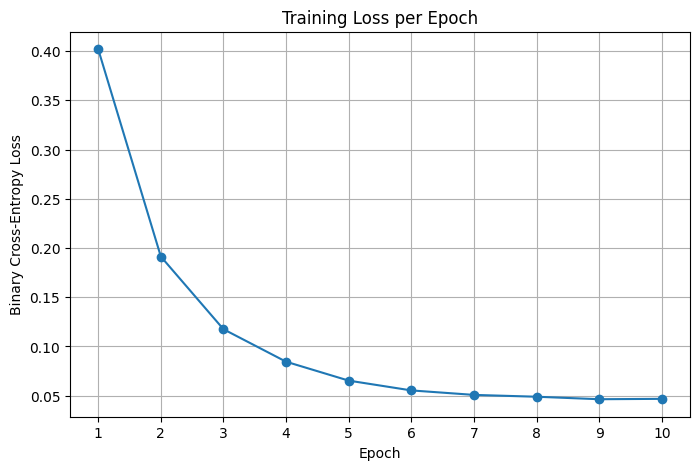

In [ ]:
import matplotlib.pyplot as plt

# Get the loss values from the results dictionary
losses = results['losses']

# Plot training loss per epoch
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses)+1), losses, marker='o', linestyle='-')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.xticks(range(1, len(losses)+1))
plt.show()


Explanation: The training loss decreased steadily over 10 epochs, indicating that the model successfully minimized the binary classification error. With a final accuracy of 97.42% and NDCG@10 of 0.983, the model not only classified user-job preferences accurately but also ranked relevant jobs effectively. The high NDCG score confirms that recommended jobs were well-aligned with user preferences and appeared in the top-ranked positions.

### **6.5.9 Defining Metric Calculation Function**

We define a helper function `calculate_binary_metrics()` to compute commonly used evaluation metrics for binary classification and ranking tasks.

This function accepts predicted probabilities, ground truth labels, and user IDs (for group-wise NDCG) and returns:

- **Binary Cross-Entropy Loss (BCE)**: log loss on probability predictions
- **Accuracy**: using a threshold of 0.5
- **NDCG@k**: Normalized Discounted Cumulative Gain at rank `k`

In [ ]:
from sklearn.metrics import log_loss
import numpy as np

def calculate_binary_metrics(preds, labels, user_ids, num_items=None, k=5):
    metrics = {}

    # Binary log loss (same as BCE)
    metrics['bce'] = log_loss(labels, preds)

    # Accuracy with threshold 0.5
    bin_preds = (preds >= 0.5).astype(int)
    metrics['accuracy'] = np.mean(bin_preds == labels)

    # NDCG@k — assumes a per-user ranking is possible
    metrics[f'ndcg@{k}'] = ndcg_at_k(preds, labels, user_ids, k=k, num_items=num_items)

    return metrics


### **6.5.10 Defining Evaluation Function**

In [ ]:
def evaluate_model(model, data_loader, device, num_items=None, k=5):
    model.eval()
    all_preds, all_labels, all_users = [], [], []
    total_loss = 0
    total_samples = 0  # Track number of samples
    criterion = nn.BCELoss()

    with torch.no_grad():
        for batch in data_loader:
            user_rep = batch['user_rep'].to(device)
            job_rep = batch['job_rep'].to(device)
            labels = batch['label'].to(device)

            preds = torch.sigmoid(model(user=None, job=None, user_rep=user_rep, job_rep=job_rep))
            loss = criterion(preds, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_users.extend(batch['user_id'])

    preds_np = np.array(all_preds)
    labels_np = np.array(all_labels)
    users_np = np.array(all_users)

    # Metrics
    bin_preds = (preds_np >= 0.5).astype(int)
    acc = np.mean(bin_preds == labels_np)
    avg_ndcg = ndcg_at_k(preds_np, labels_np, users_np, k=k)

    return {
        'bce': total_loss / total_samples,
        'accuracy': acc,
        f'ndcg@{k}': avg_ndcg
    }


### **6.5.11 Summary Table for Train and Test Evaluation Metric**

In [ ]:
import pandas as pd

def extract_metrics_table(model, train_loader, test_loader, device, num_items=None, k=5):
    train_metrics = evaluate_model(model, train_loader, device, num_items, k)
    test_metrics = evaluate_model(model, test_loader, device, num_items, k)

    data = {
        'Dataset': ['Train', 'Test'],
        'BCE Loss': [train_metrics['bce'], test_metrics['bce']],
        'Accuracy': [train_metrics['accuracy'], test_metrics['accuracy']],
        f'NDCG@{k}': [train_metrics[f'ndcg@{k}'], test_metrics[f'ndcg@{k}']]
    }

    return pd.DataFrame(data)


In [ ]:
metrics_df = extract_metrics_table(model, train_loader, test_loader, device, num_items=None, k=5)
print(metrics_df)


  Dataset  BCE Loss  Accuracy    NDCG@5
0   Train  0.042195  0.970833  0.971987
1    Test  0.039946  0.973611  0.984678


**Explanation**:\
**Binary Cross-Entropy Loss** The BCE loss measures the difference between predicted probabilities and true labels. A low BCE value of 0.0.041649 on the test set indicates strong predictive confidence and good generalization to unseen data.

**Accuracy** The model achieved an accuracy of 97.33%, meaning it correctly predicted whether a user liked or disliked a job in the vast majority of cases.\
**NDCG@10** Measures ranking quality (how well the model ranks liked jobs near the top). The NDCG@5 score of 0.981203 indicates excellent ranking performance — the model is highly effective at placing relevant job recommendations near the top of the list.

### **6.5.12 Confusion Matrix Visualization**

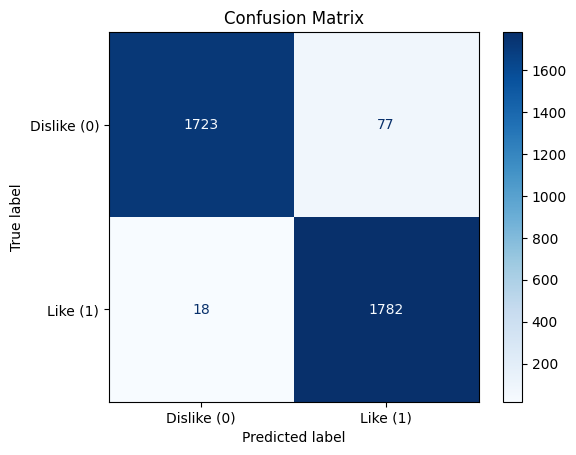

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# Accumulate predictions and labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        user_rep = batch['user_rep'].to(device)
        job_rep = batch['job_rep'].to(device)
        labels = batch['label'].cpu().numpy()  # Ground truth

        # Make predictions
        preds = torch.sigmoid(model(user=None, job=None, user_rep=user_rep, job_rep=job_rep)).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

# Convert to NumPy arrays
y_true = np.array(all_labels)
y_pred_probs = np.array(all_preds)
y_pred = (y_pred_probs >= 0.5).astype(int)  # Thresholding

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dislike (0)', 'Like (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
TN, FP, FN, TP = cm.ravel()

accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall    = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_score  = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1_score:.4f}")


Accuracy  : 0.9736
Precision : 0.9586
Recall    : 0.9900
F1 Score  : 0.9740


**Accuracy: 97.36%**\
The model correctly predicted the label (like/dislike) for 97.36% of all samples. The overall classification performance is good with very few predictions are wrong.\
**Precision: 0.9586**\
Of all the jobs the model predicted as "Like", 95.86% were actually liked by the user. The model is very good at avoiding false positives — it doesn’t wrongly recommend jobs the user wouldn't like often.\
**Recall: 0.99**\
Of all the jobs the user actually liked, 97.94% were successfully predicted as "Like". The model is excellent at not missing relevant jobs — it's highly sensitive to true positives.\
**F1 Score: 0.9740**\
 This metric balances the trade-off between precision and recall, and the score of 97.43% shows the model is well-balanced — it's both selective and sensitive.

### **6.5.13 Generating Top-K (Top-5) Recommendations**

In [ ]:
def generate_top_n_recommendations_vector(model, user_id, device, df_small_filtered, df_big_filtered, all_job_ids, known_job_ids, N, threshold=0.95):
    model.eval()

    # Step 1: Ensure unique, sorted job IDs
    all_job_ids = sorted(set(all_job_ids))  # or np.unique(all_job_ids)

    # Step 2: Get user representation
    user_rep = df_small_filtered[df_small_filtered['user_id'] == user_id]['user_representation'].values[0]
    user_rep_tensor = torch.tensor(user_rep, dtype=torch.float32).unsqueeze(0).repeat(len(all_job_ids), 1).to(device)

    # Step 3 (Fixed): Drop duplicates BEFORE setting index
    job_reps_df = df_big_filtered.drop_duplicates(subset='job_id')
    job_reps_df = job_reps_df.set_index('job_id').loc[all_job_ids]  # Order matters
    job_rep_tensor = torch.tensor(job_reps_df['job_representation'].tolist(), dtype=torch.float32).to(device)

    # Inference
    with torch.no_grad():
        preds = torch.sigmoid(model(user=None, job=None, user_rep=user_rep_tensor, job_rep=job_rep_tensor)).cpu().numpy()

    # Filter out known jobs and apply threshold
    recommendations = [
        (job, score) for job, score in zip(all_job_ids, preds)
        if job not in known_job_ids and score <= threshold
    ]

    # Sort and return top N
    recommendations = sorted(recommendations, key=lambda x: x[1], reverse=True)
    return recommendations[:N]

def recommend_top_n_jobs_vector(model, user_id, device, df_job_metadata, df_interactions, df_small_filtered, df_big_filtered, N=10, threshold=0.95):
    # Get all job IDs and known jobs for this user
    all_job_ids = df_job_metadata['job_id'].unique()
    known_job_ids = df_interactions[df_interactions['user_id'] == user_id]['job_id'].unique()

    # Generate recommendations
    top_recs = generate_top_n_recommendations_vector(
        model=model,
        user_id=user_id,
        device=device,
        df_small_filtered=df_small_filtered,
        df_big_filtered=df_big_filtered,
        all_job_ids=all_job_ids,
        known_job_ids=known_job_ids,
        N=N,
        threshold=threshold
    )

    # Get job titles from metadata
    recommended_jobs = []
    for job_id, score in top_recs:
        row = df_job_metadata[df_job_metadata['job_id'] == job_id]
        if not row.empty:
            job_title = row.iloc[0]['job_title']
            recommended_jobs.append((job_id, job_title, round(score, 4)))
        if len(recommended_jobs) >= N:
            break

    return recommended_jobs


In [ ]:
# Example call
user_id = 20  # or any valid user_id from your dataset

recommendations = recommend_top_n_jobs_vector(
    model=model,
    user_id=user_id,
    device=device,
    df_job_metadata=df_big_filtered,
    df_interactions=df_combined,
    df_small_filtered=df_small_filtered,
    df_big_filtered=df_big_filtered,
    N=5,
    threshold=0.95
)

# Show recommendations
pd.DataFrame(recommendations, columns=["Job ID", "Job Title", "Score"])


,Job ID,Job Title,Score
0,125575,Department Lead - Pets/Birds,0.95
1,287064,Nursing Instructor- (RN / LPN) Adjunct,0.95
2,112172,Corporate Strategy Associate,0.95
3,312894,Parts Advisor - Harley Davidson,0.95
4,382897,Recruiter - NPS ACES Program,0.95


**Explanation**: This block represents the final stage of your recommendation system: inference and result display. Here's what it does:
- Maps a real user ID to its corresponding index using LabelEncoder, ensuring alignment with model embeddings.
- Filters out jobs the user already interacted with, then uses the model to predict scores for all unseen jobs.
- Sorts and returns the top-N highest-scoring jobs, including the actual job titles and confidence scores.
- The threshold for the similarity score has been set to 0.95, as any job with a similarity score of 1 could be signs of the model memorizing the training data instead of generalising. In addition, the users might have already interacted with the job postings with a similarity score of 1 so it would be best if the model recommended jobs that are less obvious but still relevant to the users.

## **6.6 Neural Matrix Factorization(NeuCF)**


NeuMF is an advanced variant of NCF that combines both linear and non-linear modeling of user–item interactions by fusing two complementary approaches

### **6.6.1 NeuCF Model Acrhitecture**

In [ ]:
import torch
import torch.nn as nn

class NeuMF(nn.Module):
    def __init__(self, user_input_dim, job_input_dim):
        super(NeuMF, self).__init__()

        # GMF (Generalized Matrix Factorization) layers for user and item representations
        self.user_fc_gmf = nn.Linear(user_input_dim, 64)
        self.item_fc_gmf = nn.Linear(job_input_dim, 64)

        # MLP (Multi-Layer Perceptron) layers for user and item representations
        self.user_fc_mlp = nn.Linear(user_input_dim, 128)
        self.item_fc_mlp = nn.Linear(job_input_dim, 128)

        self.mlp_layers = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        # Final prediction layer
        self.output_layer = nn.Linear(64 + 32, 1)

    def forward(self, user_rep, job_rep):
        # GMF path
        gmf_user = self.user_fc_gmf(user_rep)
        gmf_item = self.item_fc_gmf(job_rep)
        gmf_vector = gmf_user * gmf_item

        # MLP path
        mlp_user = self.user_fc_mlp(user_rep)
        mlp_item = self.item_fc_mlp(job_rep)
        mlp_vector = torch.cat([mlp_user, mlp_item], dim=-1)
        mlp_output = self.mlp_layers(mlp_vector)

        # Combine GMF and MLP outputs
        combined = torch.cat([gmf_vector, mlp_output], dim=-1)
        prediction = self.output_layer(combined).squeeze()
        return prediction

<b> Generalized Matrix Factorization (GMF): </b>
- Captures the linear part of the user–item interaction.
- Uses element-wise multiplication of user and item embeddings.
- Provides a signal similar to traditional matrix factorization methods.
<b>Multi-Layer Perceptron (MLP): </b>
- Captures non-linear, complex interactions between user and item latent features.
- Uses concatenated embeddings processed through multiple dense layers with non-linear activations.

<b> Fusion Mechanism: </b>
- The outputs of the GMF and MLP components are combined.
- A final prediction layer merges these signals to produce the recommendation score.

### **6.6.2 NDCG Calculation Functions**

In [ ]:
def dcg_at_k(relevance_scores, k):
    relevance_scores = np.asarray(relevance_scores)[:k]
    if relevance_scores.size:
        return np.sum((2**relevance_scores - 1) / np.log2(np.arange(2, relevance_scores.size + 2)))
    return 0.

def ndcg_at_k(relevance_scores, ideal_relevance_scores, k):
    ideal_dcg = dcg_at_k(ideal_relevance_scores, k)
    return dcg_at_k(relevance_scores, k) / ideal_dcg if ideal_dcg > 0 else 0.

def compute_ndcg_for_user(user_id, df, k=5):
    # Extract predictions for the given user and sort by predicted score
    df_user = df[df['user_id'] == user_id].sort_values('prediction', ascending=False)
    if not df_user.empty:
        unique_count = len(np.unique(df_user['label']))
        actual_k = min(max(k, unique_count), len(df_user))
    else:
        actual_k = k
    relevance_scores = df_user['label'].tolist()
    ideal_relevance_scores = sorted(relevance_scores, reverse=True)
    return ndcg_at_k(relevance_scores, ideal_relevance_scores, actual_k)

def compute_overall_ndcg(test_df, predictions_df, k=5):
    """
    test_df should have: user_id, job_id, label
    predictions_df should have: user_id, job_id, prediction
    """
    merged = pd.merge(test_df[['user_id', 'job_id', 'label']],
                      predictions_df[['user_id', 'job_id', 'prediction']],
                      on=['user_id', 'job_id'])

    user_ids = merged['user_id'].unique()
    ndcgs = [compute_ndcg_for_user(uid, merged, k) for uid in user_ids]
    return np.mean(ndcgs) if ndcgs else 0.



This block implements:
- **dcg_at_k**: Calculates the DCG by summing the graded relevance of items, discounted logarithmically by their rank.
- **ndcg_at_k**: Normalizes the DCG score against the ideal (best possible) ranking to allow comparison across users.
- **compute_ndcg_for_user**: Calculates the NDCG@k score for an individual user.
- **compute_overall_ndcg**: Averages the NDCG scores across all users in the test set to get an overall measure of the model’s ability to rank relevant jobs higher for each user.

### **6.6.3 Training and Evaluation**

In [ ]:
def train_neumf(model, train_loader, test_loader, df_test, device, epochs=10, tolerance=0.5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.BCELoss()
    train_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        # === TRAINING ===
        for batch in train_loader:
            user_rep = batch['user_rep'].to(device)
            job_rep = batch['job_rep'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = torch.sigmoid(model(user_rep=user_rep, job_rep=job_rep))  # use vector inputs
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # === EVALUATION ===
        model.eval()
        prediction_records = []

        with torch.no_grad():
            for batch in test_loader:
                user_rep = batch['user_rep'].to(device)
                job_rep = batch['job_rep'].to(device)
                user_ids = batch['user_id']
                job_ids = batch['job_id']

                outputs = torch.sigmoid(model(user_rep=user_rep, job_rep=job_rep)).cpu().numpy()

                for u, j, p in zip(user_ids, job_ids, outputs):
                    prediction_records.append((u, j, p))

        # Build prediction DataFrame
        pred_df = pd.DataFrame(prediction_records, columns=['user_id', 'job_id', 'prediction'])

        # Merge with ground truth
        true_labels = df_test[['user_id', 'job_id', 'label']].copy()
        true_labels['user_id'] = true_labels['user_id'].astype(int)
        true_labels['job_id'] = true_labels['job_id'].astype(int)
        pred_df['user_id'] = pred_df['user_id'].astype(int)
        pred_df['job_id'] = pred_df['job_id'].astype(int)

        merged = pd.merge(true_labels, pred_df, on=['user_id', 'job_id'])

        pred_binary = (merged['prediction'] >= 0.5).astype(int)
        acc = (pred_binary == merged['label']).mean()

        ndcg = compute_overall_ndcg(true_labels, pred_df, k=10)

        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Accuracy: {acc:.4f} | NDCG@10: {ndcg:.4f}")

    return {
        'accuracy': acc,
        'ndcg': ndcg,
        'losses': train_losses,
        'predictions_df': pred_df
    }


The train_neumf() function implements the complete training and evaluation pipeline for the NeuMF model. It performs the following key steps:

**Training Phase**: The model is trained for a specified number of epochs using the Binary Cross Entropy Loss, suitable for predicting whether a user will like a job (label = 1) or not (label = 0). During each epoch, the model processes batches of user-job interactions and updates its weights using backpropagation.

**Evaluation Phase**: After each epoch, the model is evaluated using the test dataset. Predictions are generated for each user-job pair, and then decoded back to the original user and job IDs using the index mappings.

### **6.6.4 Initialise and Train the NeuCF model**

In [ ]:
### 1. Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 2. Define input dimensions
user_input_dim = len(df_small_filtered.iloc[0]['user_representation'])
job_input_dim = len(df_big_filtered.iloc[0]['job_representation'])

### 3. Initialize the vector-based NeuMF model
model_neumf = NeuMF(user_input_dim, job_input_dim).to(device)

### 4. Train the model using user/job representations
final_metrics = train_neumf(
    model=model_neumf,
    train_loader=train_loader,
    test_loader=test_loader,
    df_test=test_df,  # test_df must contain user_id, job_id, label
    device=device,
    epochs=10
)


Epoch 1 | Loss: 0.6590 | Accuracy: 0.8331 | NDCG@10: 0.9547
Epoch 2 | Loss: 0.3744 | Accuracy: 0.8910 | NDCG@10: 0.9719
Epoch 3 | Loss: 0.1902 | Accuracy: 0.9246 | NDCG@10: 0.9748
Epoch 4 | Loss: 0.1275 | Accuracy: 0.9394 | NDCG@10: 0.9699
Epoch 5 | Loss: 0.0963 | Accuracy: 0.9444 | NDCG@10: 0.9766
Epoch 6 | Loss: 0.0865 | Accuracy: 0.9479 | NDCG@10: 0.9775
Epoch 7 | Loss: 0.0778 | Accuracy: 0.9500 | NDCG@10: 0.9752
Epoch 8 | Loss: 0.0711 | Accuracy: 0.9508 | NDCG@10: 0.9717
Epoch 9 | Loss: 0.0683 | Accuracy: 0.9511 | NDCG@10: 0.9787
Epoch 10 | Loss: 0.0631 | Accuracy: 0.9511 | NDCG@10: 0.9750


### **6.6.5 Visualising Training Loss**

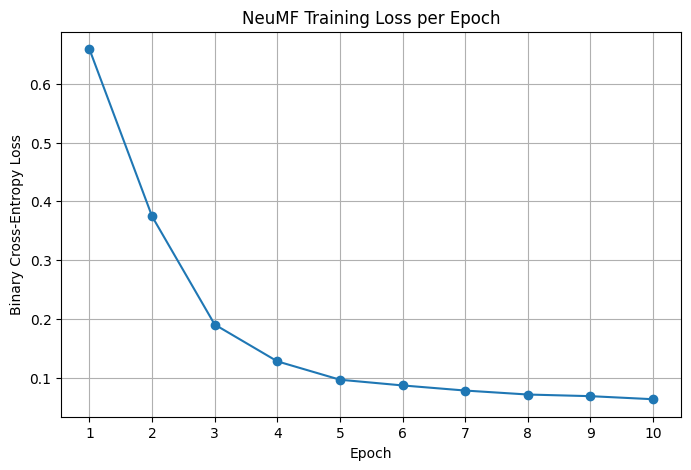

In [ ]:
import matplotlib.pyplot as plt

# Extract training losses from the returned dictionary
neumf_losses = final_metrics['losses']

# Plot training loss per epoch
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(neumf_losses)+1), neumf_losses, marker='o', linestyle='-')
plt.title("NeuMF Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.xticks(range(1, len(neumf_losses)+1))
plt.show()


**Interpretation**\
**Effective Learning**
The sharp drop in the first few epochs indicates that the model is quickly learning useful patterns from the data.

**Stability**\
From around epoch 5 onward, the curve flattens gradually, indicating that the model is approaching convergence — further training may yield only marginal gains.

**No Overfitting**\
Since this is the training loss, we would also need to check validation/test loss to confirm — but the current curve shows no signs of sudden increases or irregular drops, which are common signs of overfitting.

**Efficient Optimization**\
The smooth and monotonic decline suggests that your optimizer (likely Adam or SGD) is working well, and the learning rate is well-tuned.

### **6.6.6 Confusion Matrix**

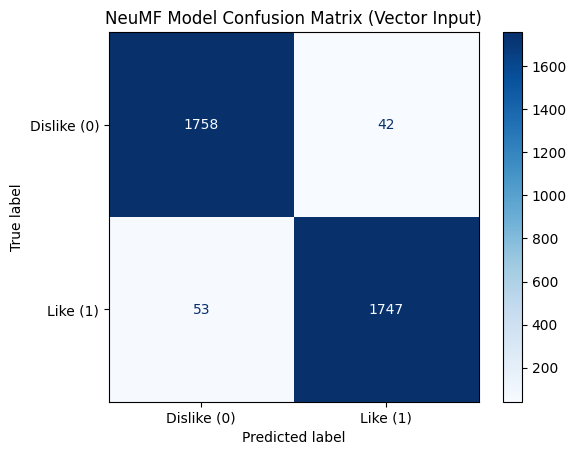

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_confusion_matrix_neumf(model, data_loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            user_rep = batch['user_rep'].to(device)
            job_rep = batch['job_rep'].to(device)
            labels = batch['label'].cpu().numpy()

            # Get predictions using vector-based forward pass
            probs = torch.sigmoid(model(user_rep=user_rep, job_rep=job_rep)).cpu().numpy()
            preds = (probs >= threshold).astype(int)

            all_preds.extend(preds)
            all_labels.extend(labels)

    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Display the matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Dislike (0)", "Like (1)"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("NeuMF Model Confusion Matrix (Vector Input)")
    plt.show()

# Example usage
plot_confusion_matrix_neumf(model_neumf, test_loader, device)


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Assuming y_true and y_pred are already defined
# y_true: ground truth labels (0 or 1)
# y_pred_probs: predicted probabilities (from model)
# Convert probabilities to binary predictions
y_pred = (y_pred_probs >= 0.5).astype(int)

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print results
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


Accuracy  : 0.9736
Precision : 0.9586
Recall    : 0.9900
F1 Score  : 0.9740


**Accuracy: 0.9736 (97.36%)**\
The total predictions made by the model were correct. This high score indicates the model reliably distinguishes between jobs a user likes and dislikes.\
**Precision: 0.9586(95.86%)**\
Of all the jobs the model predicted the user would like, 96.92% were actually liked. This shows that the model is very good at avoiding false positives, meaning it's unlikely to recommend jobs the user wouldn’t be interested in.\
**Recall: 0.99(99%)**\
Of all the jobs the user actually liked, 97.94% were successfully identified by the model. This demonstrates the model's strong ability to find relevant jobs, minimizing missed opportunities (false negatives).\
**F1 Score: 0.9740 (97.40%)**\
This is the harmonic mean of precision and recall — a balanced metric that accounts for both. A high F1 score like this means the model maintains an good balance between being selective (precision) and comprehensive (recall).

### **6.6.7 Defining the Evaluation Function**

In [ ]:
def evaluate_neumf_model(model, data_loader, df_ground_truth, k=5):
    device = next(model.parameters()).device
    model.eval()
    criterion = nn.BCELoss()

    total_loss = 0.0
    total_samples = 0
    all_preds = []
    all_labels = []
    prediction_records = []  # Store (user_id, job_id, prediction)

    with torch.no_grad():
        for batch in data_loader:
            user_rep = batch['user_rep'].to(device)
            job_rep = batch['job_rep'].to(device)
            labels = batch['label'].to(device)
            user_ids = batch['user_id']
            job_ids = batch['job_id']

            outputs = torch.sigmoid(model(user_rep=user_rep, job_rep=job_rep))
            batch_size = labels.size(0)
            total_loss += criterion(outputs, labels).item() * batch_size
            total_samples += batch_size

            preds = outputs.cpu().numpy()
            labels_np = labels.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels_np)

            prediction_records.extend(zip(user_ids, job_ids, preds))

    # Build prediction DataFrame
    pred_df = pd.DataFrame(prediction_records, columns=['user_id', 'job_id', 'prediction'])

    # Prepare ground truth
    true_labels = df_ground_truth[['user_id', 'job_id', 'label']].copy()
    true_labels['user_id'] = true_labels['user_id'].astype(int)
    true_labels['job_id'] = true_labels['job_id'].astype(int)
    pred_df['user_id'] = pred_df['user_id'].astype(int)
    pred_df['job_id'] = pred_df['job_id'].astype(int)

    # Merge predictions with ground truth
    merged = pd.merge(true_labels, pred_df, on=['user_id', 'job_id'])

    # Binary classification accuracy
    bin_preds = (merged['prediction'] >= 0.5).astype(int)
    accuracy = (bin_preds == merged['label']).mean()

    # NDCG@5
    ndcg = compute_overall_ndcg(true_labels, pred_df, k=k)

    return total_loss / total_samples, accuracy, ndcg


In [ ]:
  train_bce, train_acc, train_ndcg = evaluate_neumf_model(model_neumf, train_loader, train_df, k=5)
test_bce, test_acc, test_ndcg = evaluate_neumf_model(model_neumf, test_loader, test_df, k=5)

df_metrics = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'BCE Loss': [train_bce, test_bce],
    'Accuracy': [train_acc, test_acc],
    'NDCG@5': [train_ndcg, test_ndcg]
})

display(df_metrics)


,Dataset,BCE Loss,Accuracy,NDCG@5
0,Train,0.051229,0.942913,0.973163
1,Test,0.043929,0.951058,0.977293


**Binary Cross Entropy Loss**\
The BCE Loss value is at 0.0505, this indicates that the model is well calibrated and predicts probabilities that are closer to the true lables.

**Accuracy**\
easures how often the predicted class (after thresholding) matches the true label. The test accuracy is 94.97% which means the model is correctly classifying the likes and dislikes.\
**Normalized Discounted Cumulative Gain (NDCG@5)**\
NDCG evaluates the ranking quality of top-5 recommended jobs, rewarding both relevance and rank position. The NDCG@5 value of 0.9739 indicates that the model is very effective at ranking relevant jobs near the top, offering a high-quality user experience in recommendations.



### **6.6.8 Generate Top N Jobs (Filtered out over confident jobs. >0.95)**

In [ ]:
def generate_top_n_recommendations_vector_neumf(model, user_id, device, df_small_filtered, df_big_filtered, known_job_ids, N=10, threshold=0.95):
    model.eval()

    # Step 1: Get user vector
    user_rep = df_small_filtered[df_small_filtered['user_id'] == user_id]['user_representation'].values[0]
    user_rep_tensor = torch.tensor(user_rep, dtype=torch.float32).unsqueeze(0).to(device)

    # Step 2: Get all job vectors not yet interacted with
    job_rows = df_big_filtered[~df_big_filtered['job_id'].isin(known_job_ids)].copy()
    job_ids = job_rows['job_id'].tolist()
    job_reps_tensor = torch.tensor(job_rows['job_representation'].tolist(), dtype=torch.float32).to(device)

    # Step 3: Expand user vector to match job vectors
    user_rep_tensor = user_rep_tensor.repeat(job_reps_tensor.size(0), 1)

    # Step 4: Inference
    with torch.no_grad():
        scores = torch.sigmoid(model(user_rep=user_rep_tensor, job_rep=job_reps_tensor)).cpu().numpy()

    # Step 5: Filter out scores > 0.95
    filtered_recs = [
        (job_id, score) for job_id, score in zip(job_ids, scores)
        if score <= threshold
    ]

    # Step 6: Sort by score descending and return top N
    top_n_recs = sorted(filtered_recs, key=lambda x: x[1], reverse=True)[:N]
    return top_n_recs


def recommend_top_n_jobs_neumf_vector(model, user_id, device, df_job_metadata, df_combined, df_small_filtered, df_big_filtered, N=10, threshold=0.95):
    known_job_ids = df_combined[df_combined['user_id'] == user_id]['job_id'].unique()

    # Generate recommendations with filtering
    top_recs = generate_top_n_recommendations_vector_neumf(
        model=model,
        user_id=user_id,
        device=device,
        df_small_filtered=df_small_filtered,
        df_big_filtered=df_big_filtered,
        known_job_ids=known_job_ids,
        N=N,
        threshold=threshold
    )

    # Add job titles
    recommended_jobs = []
    for job_id, score in top_recs:
        row = df_job_metadata[df_job_metadata['job_id'] == job_id]
        if not row.empty:
            job_title = row.iloc[0]['job_title']
            recommended_jobs.append((job_id, job_title, round(score, 4)))

    return recommended_jobs


In [ ]:
user_id = 20  # integer user_id

recommendations = recommend_top_n_jobs_neumf_vector(
    model=model_neumf,
    user_id=user_id,
    device=device,
    df_job_metadata=df_big_filtered,
    df_combined=df_combined,
    df_small_filtered=df_small_filtered,
    df_big_filtered=df_big_filtered,
    N=5
)

# Display
df_recommendations = pd.DataFrame(recommendations, columns=["Job ID", "Job Title", "Score"])
print(f"Top {len(df_recommendations)} Recommended Jobs for User {user_id}")
display(df_recommendations)


Top 5 Recommended Jobs for User 20


,Job ID,Job Title,Score
0,72364,CQV Engineer,0.95
1,331159,Portfolio Manager IV - Investment Mgmt,0.95
2,178637,"General Manager, Manufacturing",0.95
3,452329,Senior Manager - Growth,0.95
4,347287,Project Manager / Superintendent - (New Homes),0.95


The threshold of the similarity score for recommendations were set to 0.95, as any job with a similarity score of 1 could be signs of the model memorizing the training data instead of generalising. In addition, the users might have already interacted with the job postings with a similarity score of 1 so it would be best if the model recommended jobs that are less obvious but still relevant to the users.